## **NMR ensemble & dynamics frustration**
In this colab we will calculate and analyze frustration patterns in an NMR ensemble of RfaH proteins. For this purpose we will use new functionalities of the frustratometer (R package). We will split the NMR ensemble and analyze its frustration by treating it as if it were a very brief molecular dynamics simulation.



Note: This notebook is largely inspired by the notebook generated for the symposium and workshop : Chaos, Panic and dis(order) in Protein Evolution by Maria Ines Freiberger and Pablo Galaz-Davison.

It also makes use of some cells from the IBM3202 course taught by my professor and tutor Cesar Ramirez-Sarmiento at PUC University.

## Part 1 :

 ### We are going to test the Frustratometer, using more standar functionalities




We are going to install the minimum libraries to be able to run the **frustratometer** in colab!

In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
#Install biopython and visualization
!pip install biopython py3Dmol
#Downgrade rpy para correr frustraR
!pip install rpy2==3.5.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 21.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.7/201.7 kB 8.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for rpy2: filename=rpy2-3.5.1-cp310-cp310-linux_x86_64.whl size=314934 sha256=489770b88d3f56595294af7f82b0b2a77421994b5fea33fde7fdfd578505ebf3
  Stored in directory: /root/.cache/pip/wheels/73/a6/ff/4e75dd1ce1cfa2b9a670cbccf6a1e41c553199e9b25f05d953
Successfully built rpy2
  Attempting uninstall: rpy2
    Found existing installation: rpy2 3.4.2
    Uninstalling rpy2-3.4.2:
      Successfully uninstalled rpy2-3.4.2


In [ ]:
!apt update -y
!apt install wget mc r-base python3 python3-pip pymol libmagick++-dev libcurl4-openssl-dev libssl-dev libgit2-dev -y
!apt install libcurl4-gnutls-dev libxml2-dev -y
!python3 -m pip install numpy biopython leidenalg
!apt install software-properties-common -y
!wget https://salilab.org/modeller/9.25/modeller_9.25-1_amd64.deb
!env KEY_MODELLER=MODELIRANJE dpkg -i modeller_9.25-1_amd64.deb

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [119 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,626 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:6 https://ppa.launchpadcontent.net/c2d4u.team/c2d4u4.0+/ubuntu jammy InRelease
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 http://security.ubuntu.com/ubuntu jammy-security InRelease [110 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [2,125 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,375 kB]
Fetched 3,732 kB in 1s (3,386 kB/s)
Reading package lists... Do

In [ ]:
#!apt-get install libxml2-dev
!apt-get install libglpk-dev

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libamd2 libbtf1 libcamd2 libccolamd2 libcholmod3 libcolamd2 libcxsparse3 libglpk40 libgmp-dev
  libgmpxx4ldbl libgraphblas-dev libgraphblas6 libklu1 libldl2 libmetis5 libmongoose2 librbio2
  libsliplu1 libspqr2 libsuitesparse-dev libsuitesparseconfig5 libumfpack5
Suggested packages:
  libiodbc2-dev gmp-doc libgmp10-doc libmpfr-dev
The following NEW packages will be installed:
  libamd2 libbtf1 libcamd2 libccolamd2 libcholmod3 libcolamd2 libcxsparse3 libglpk-dev libglpk40
  libgmp-dev libgmpxx4ldbl libgraphblas-dev libgraphblas6 libklu1 libldl2 libmetis5 libmongoose2
  librbio2 libsliplu1 libspqr2 libsuitesparse-dev libsuitesparseconfig5 libumfpack5
0 upgraded, 23 newly installed, 0 to remove and 43 not upgraded.
Need to get 23.5 MB of archives.
After this operation, 174 MB of additional disk space will be used.
Get:1 http://archive.ubun

In [ ]:
!Rscript -e "install.packages('ggrepel')"
!Rscript -e "install.packages('igraph')"
!Rscript -e "install.packages('dplyr')"
!Rscript -e "install.packages('FactoMineR')"
!Rscript -e "install.packages('Hmisc')"`
!Rscript -e "install.packages('argparse')"
!Rscript -e "install.packages('leiden')"
!Rscript -e "install.packages('magick')"
!Rscript -e "options(timeout=9999999)"
!Rscript -e "devtools::install_github('proteinphysiologylab/frustratometeR')"

Streaming output truncated to the last 5000 lines.
../inst/include/Eigen/src/Householder/HouseholderSequence.h:427:25:   required from ‘typename Eigen::internal::matrix_type_times_scalar_type<typename Eigen::internal::traits<Eigen::HouseholderSequence<VectorsType, CoeffsType, Side> >::Scalar, OtherDerived>::Type Eigen::HouseholderSequence<VectorsType, CoeffsType, Side>::operator*(const Eigen::MatrixBase<OtherDerived>&) const [with OtherDerived = Eigen::Map<Eigen::Matrix<double, -1, 1>, 0, Eigen::Stride<0, 0> >; VectorsType = Eigen::Matrix<double, -1, -1>; CoeffsType = Eigen::Matrix<double, -1, 1>; int Side = 1; typename Eigen::internal::matrix_type_times_scalar_type<typename Eigen::internal::traits<Eigen::HouseholderSequence<VectorsType, CoeffsType, Side> >::Scalar, OtherDerived>::Type = Eigen::Matrix<double, -1, 1>; typename Eigen::internal::traits<Eigen::HouseholderSequence<VectorsType, CoeffsType, Side> >::Scalar = double]’
fastLm.cpp:105:67:   required from here
../inst/include/Eig

Now, we are going to **donwload the interactive version of R**  which is usefull to calculate the frustration at the contact level (mutational and configurational).

In [ ]:
#Loading the R extension interactively
%load_ext rpy2.ipython

Then we download the monomeric form Beta CTD, which is an ensemble of NMR structures.

In [ ]:
!wget http://www.rcsb.org/pdb/files/2lcl.pdb -O 2lcl.pdb


--2024-05-27 16:22:53--  http://www.rcsb.org/pdb/files/2lcl.pdb
Resolving www.rcsb.org (www.rcsb.org)... 128.6.159.248
Connecting to www.rcsb.org (www.rcsb.org)|128.6.159.248|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.rcsb.org/pdb/files/2lcl.pdb [following]
--2024-05-27 16:22:54--  https://www.rcsb.org/pdb/files/2lcl.pdb
Connecting to www.rcsb.org (www.rcsb.org)|128.6.159.248|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://files.rcsb.org/download/2lcl.pdb [following]
--2024-05-27 16:22:54--  https://files.rcsb.org/download/2lcl.pdb
Resolving files.rcsb.org (files.rcsb.org)... 128.6.159.245
Connecting to files.rcsb.org (files.rcsb.org)|128.6.159.245|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/octet-stream]
Saving to: ‘2lcl.pdb’

2lcl.pdb                [   <=>              ]   1.61M  2.54MB/s    in 0.6s    

2024-05-27 16:22

####Visualization of the structures

In [ ]:
#Visualizing the heterotetramer
import py3Dmol
#First we assign the py3Dmol.view as view
view=py3Dmol.view()
#The following lines are used to add the addModel class
#to read the PDB files of chain B and C
view.addModel(open('/content/2lcl.pdb', 'r').read(),'pdb')
#Zooming into all visualized structures
view.zoomTo()
#Here we set the background color as white
view.setBackgroundColor('white')
#Here we set the visualization style for chain B and C
view.setStyle({'chain':'A'},{'cartoon': {'color':'blue'}})
#view.setStyle({'chain':'B'},{'cartoon': {'color':'green'}})
#view.setStyle({'chain':'C'},{'cartoon': {'color':'yellow'}})
#view.setStyle({'chain':'D'},{'cartoon': {'color':'pueple'}})
#And we finally visualize the structures using the command below
view.show()

Output hidden; open in https://colab.research.google.com to view.

Para obtener informacion relevante para el analisis

Para conocer mas información a prori sobre la proteina proveniente del PDB, se usará un par de lineas del curso IBM3202. Lab02

In [ ]:
#Crear un parse para poder extraer innformación del archivo
from Bio import SeqIO, Entrez
#Setting up your email to be able to use Entrez
Entrez.email = 'simulacra.simulacion@gmail.com'                                                            ### Enter e-mail ##3
#Here, we set up a temporary handle with our downloaded sequence in fasta format
temp = Entrez.efetch(db="protein",rettype="fasta",id="2LCL_A")
#Creating a fasta file to write our downloaded sequence
aaseq_out = open("2LCL_A.fasta",'w')
#Reading the sequence information as a string in fasta format
aaseq = SeqIO.read(temp, format="fasta")
#Writing the sequence record in fasta format
SeqIO.write(aaseq,aaseq_out,"fasta")
#Closing both the temp handle and the FASTA file
temp.close()
aaseq_out.close()

In [ ]:
from typing import Sequence
#Printing the number of amino acids as an example
print("Sequence length (aa):")
print(len(aaseq))

#Printing the description of the sequence
print("The description of the sequence is:")
#INSERT YOUR OWN COMMAND HERE
print(aaseq.description)

#Printing the accession ID of the sequence
print("The ID of the sequence is:")
#INSERT YOUR OWN COMMAND BELOW
print(aaseq.id)

#Printing the sequence
print("The sequence is:")
#INSERT YOUR OWN COMMAND BELOW
print(aaseq.seq)

Sequence length (aa):
66
The description of the sequence is:
pdb|2LCL|A Chain A, Transcriptional activator rfaH
The ID of the sequence is:
pdb|2LCL|A
The sequence is:
GAMGPKDIVDPATPYPGDKVIITEGAFEGFQAIFTEPDGEARSMLLLNLINKEIKHSVKNTEFRKL


## **Frustration calculation on the CArboxyterminal domain**

We will generate the **R script** to frustrate all the pdbs out there **in a directory**!




## Now, we  create a working directory for frustration and load the library of frustratometer to create mutational object.

In [ ]:
#create a folder to save the frustration resutls
!mkdir Results

*Now we will check frustratometeR* status

In [ ]:
%%R
library(frustratometeR)

help(package = "frustratometeR")



    consider that it could be called from a Python process. This
    results in a quasi-obligatory segfault when rpy2 is evaluating
    R code using it. On the hand, rpy2 is accounting for the
    fact that it might already be running embedded in a Python
    process. This is why:
    - Python -> rpy2 -> R -> reticulate: crashes
    - R -> reticulate -> Python -> rpy2: works

    The issue with reticulate is tracked here:
    https://github.com/rstudio/reticulate/issues/208
    File: /tmp/RtmpQnF2v5/RpackageInfo114924d3237b


		Information on package ‘frustratometeR’



Description:



Package:            frustratometeR

Type:               Package

Title:              frustratometeR

Version:            0.1.0

Authors:            Atilio O. Rausch*, Freiberger Maria I.*, R. Gonzalo

                    Parra

Maintainer:         Atilio O. Rausch <atiliorau@gmail.com>, Freiberger

                    Maria I. <mariaines.freiberger@gmail.com>, R.

                    Gonzalo Parra <gonz

# Local Frustration:

In [ ]:
#Loading the R extension interactively
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


### Primero el indice mutacional :

In [ ]:
#Loading the R extension interactively
%reload_ext rpy2.ipython


In [ ]:
%%R

library(frustratometeR)

# Especifica las rutas correctas para los directorios de PDB y resultados
#PdbsDir <- "/content/rfahB_CTD"
#ResultsDir <- "/content/rfahB_CTD/Results"

# Ejecutar la función dir_frustration con las rutas especificadas
#dir_frustration(PdbsDir = PdbsDir, Mode = "mutational", ResultsDir = ResultsDir)

dir_frustration(PdbsDir = "/content/", Mode = "mutational", ResultsDir ="/content/Results")

-----------------------------Filtering-----------------------------
-----------------------------Preparing files-----------------------------
-----------------------------Setting options-----------------------------
-----------------------------Calculating-----------------------------
-----------------------------Reorganization-----------------------------
-----------------------------Images-----------------------------
5Adens plot is stored in /content/Results/2lcl.done/Images/2lcl_mutational.png_5Adens.png
5Adens proportion plot is stored in /content/Results/2lcl.done/Images/2lcl_mutational_5Adens_around.png
Contact map is stored in /content/Results/2lcl.done/Images/2lcl_mutational_map.png
-----------------------------Visualizations-----------------------------


****Storage information****
The frustration data was stored in /content/Results/2lcl.done/FrustrationData
Graphics are stored in /content/Results/2lcl.done/Images
Visualizations are stored in /content/Results/2lcl.done/Visua

### Nota : este analisis se ejecuta para conocer la frustración para cada uno de los residuos de la secuencia de RfaH.

La información que aqui se genera servirá para orientarse y concoer mas de las graficas correspondientes

In [ ]:
from IPython.display import Image

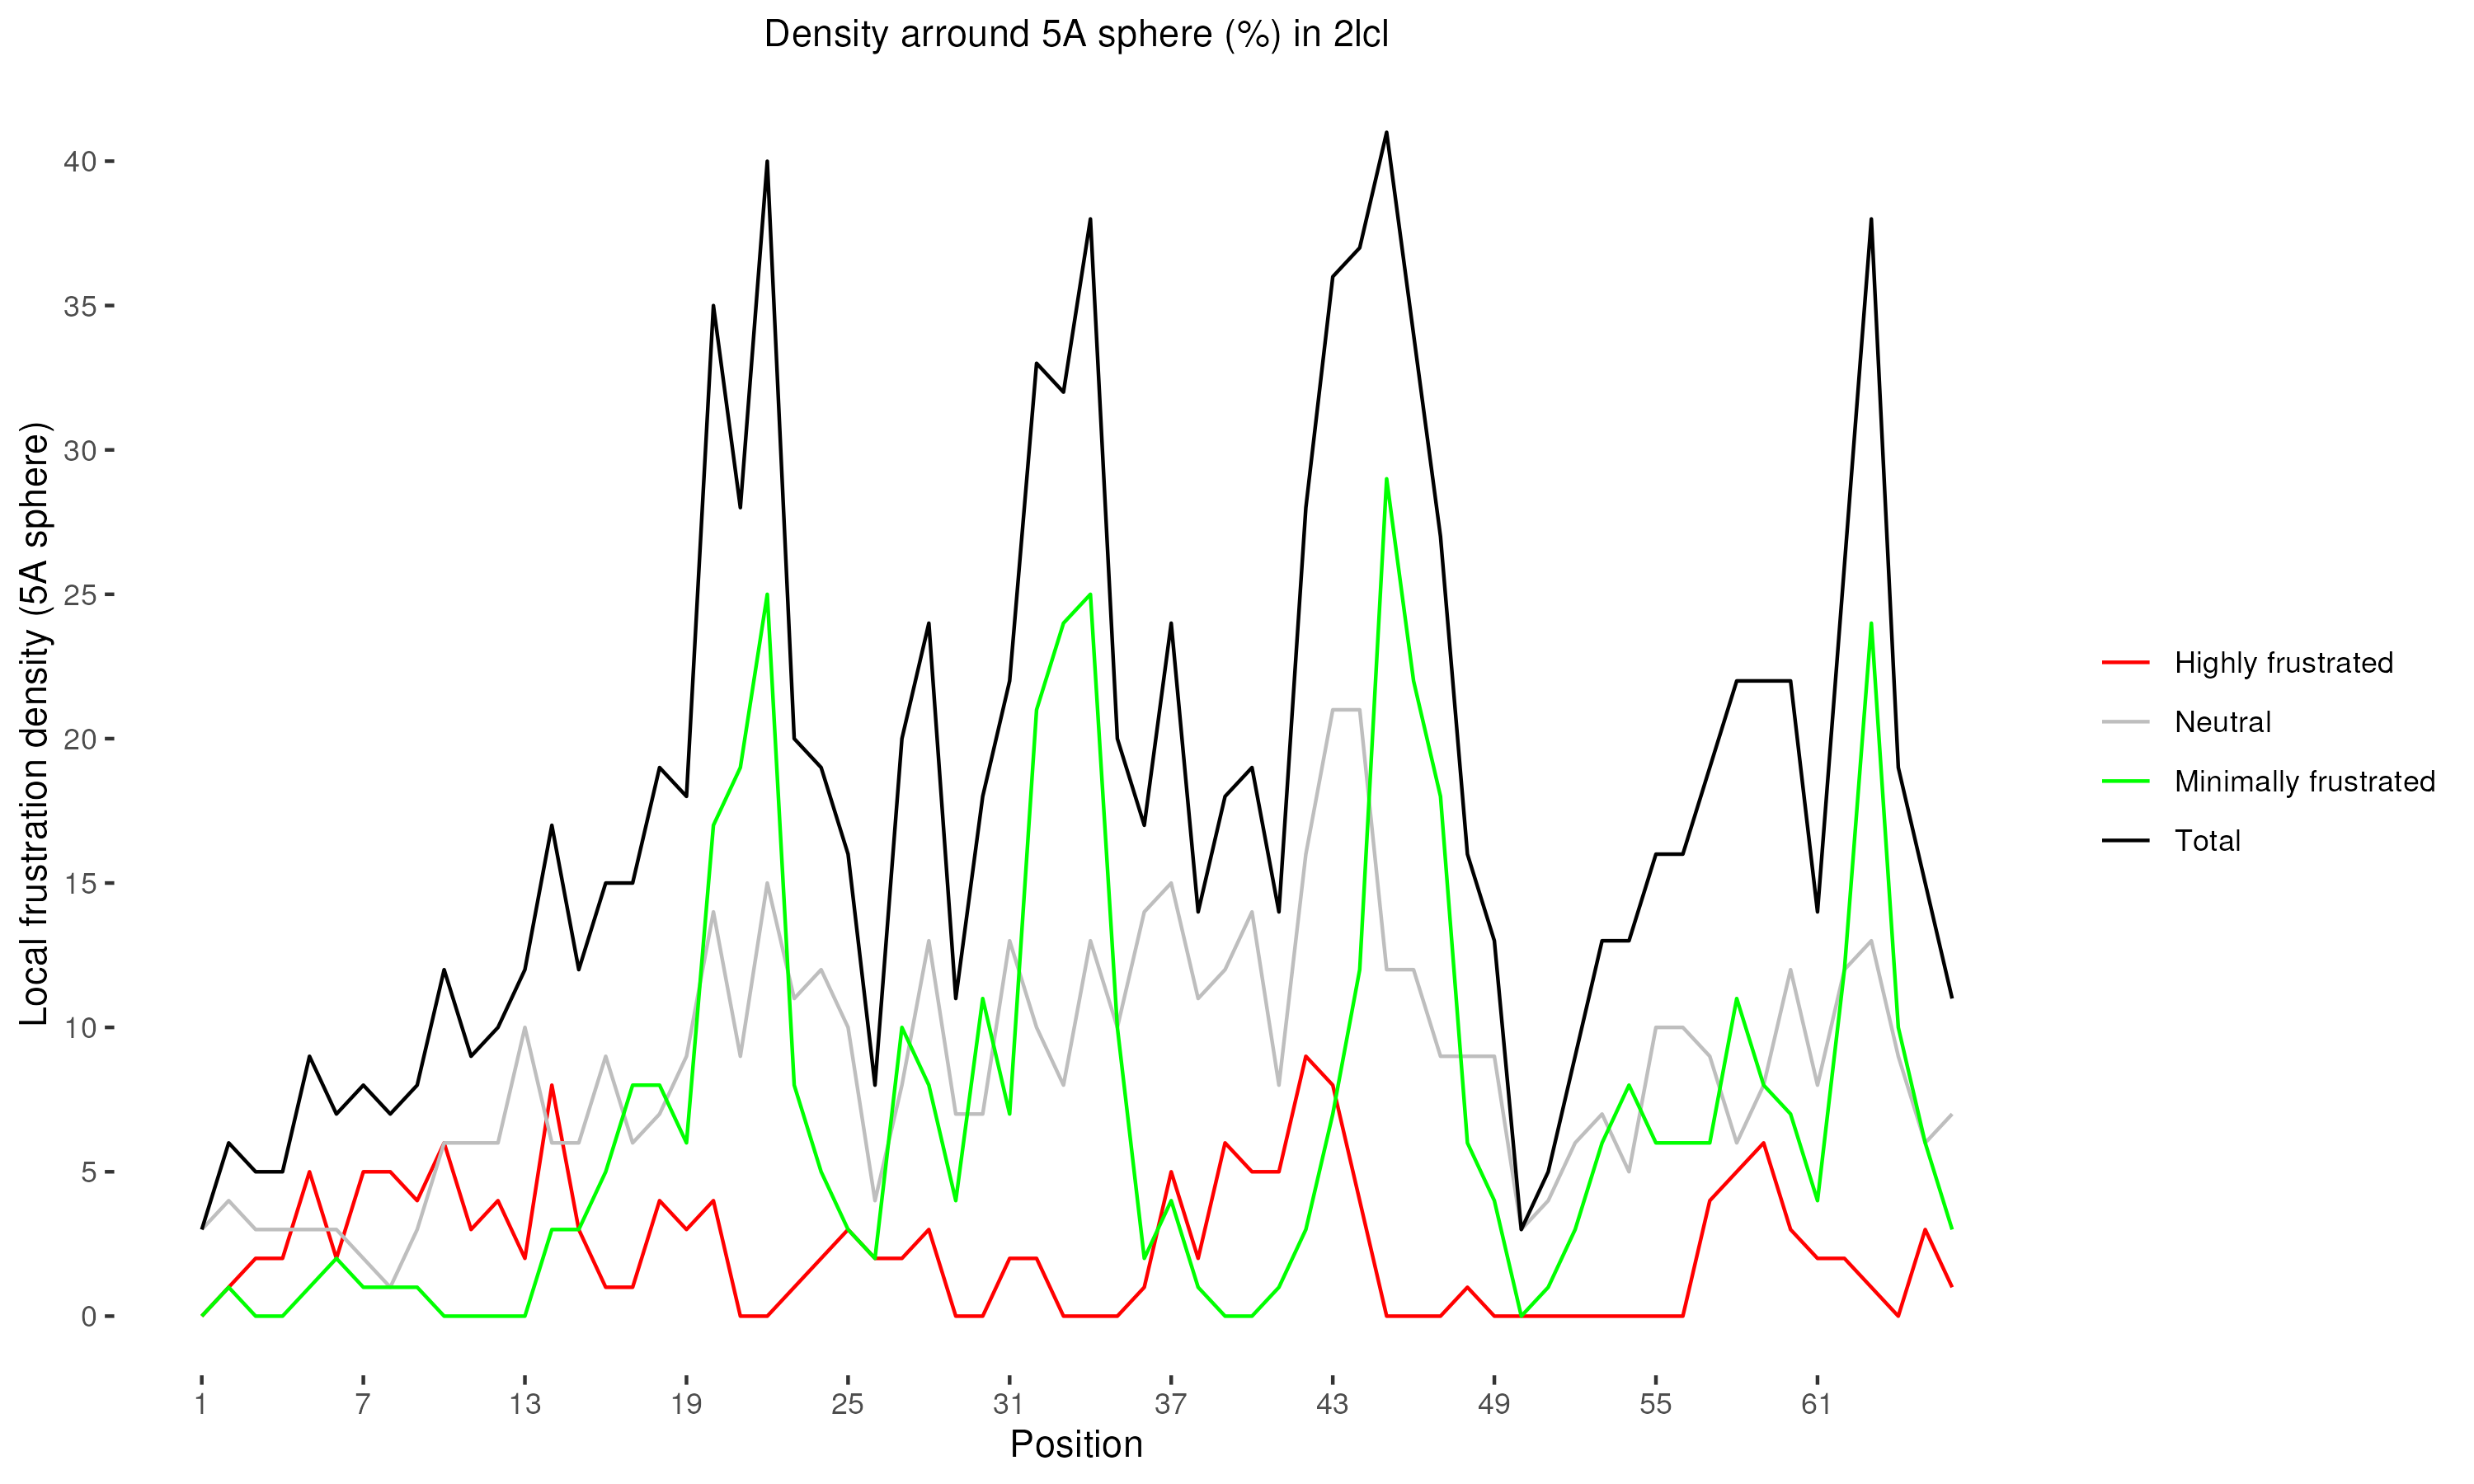

In [ ]:
Image('/content/Results/2lcl.done/Images/2lcl_mutational.png_5Adens.png', width=700, height=400)

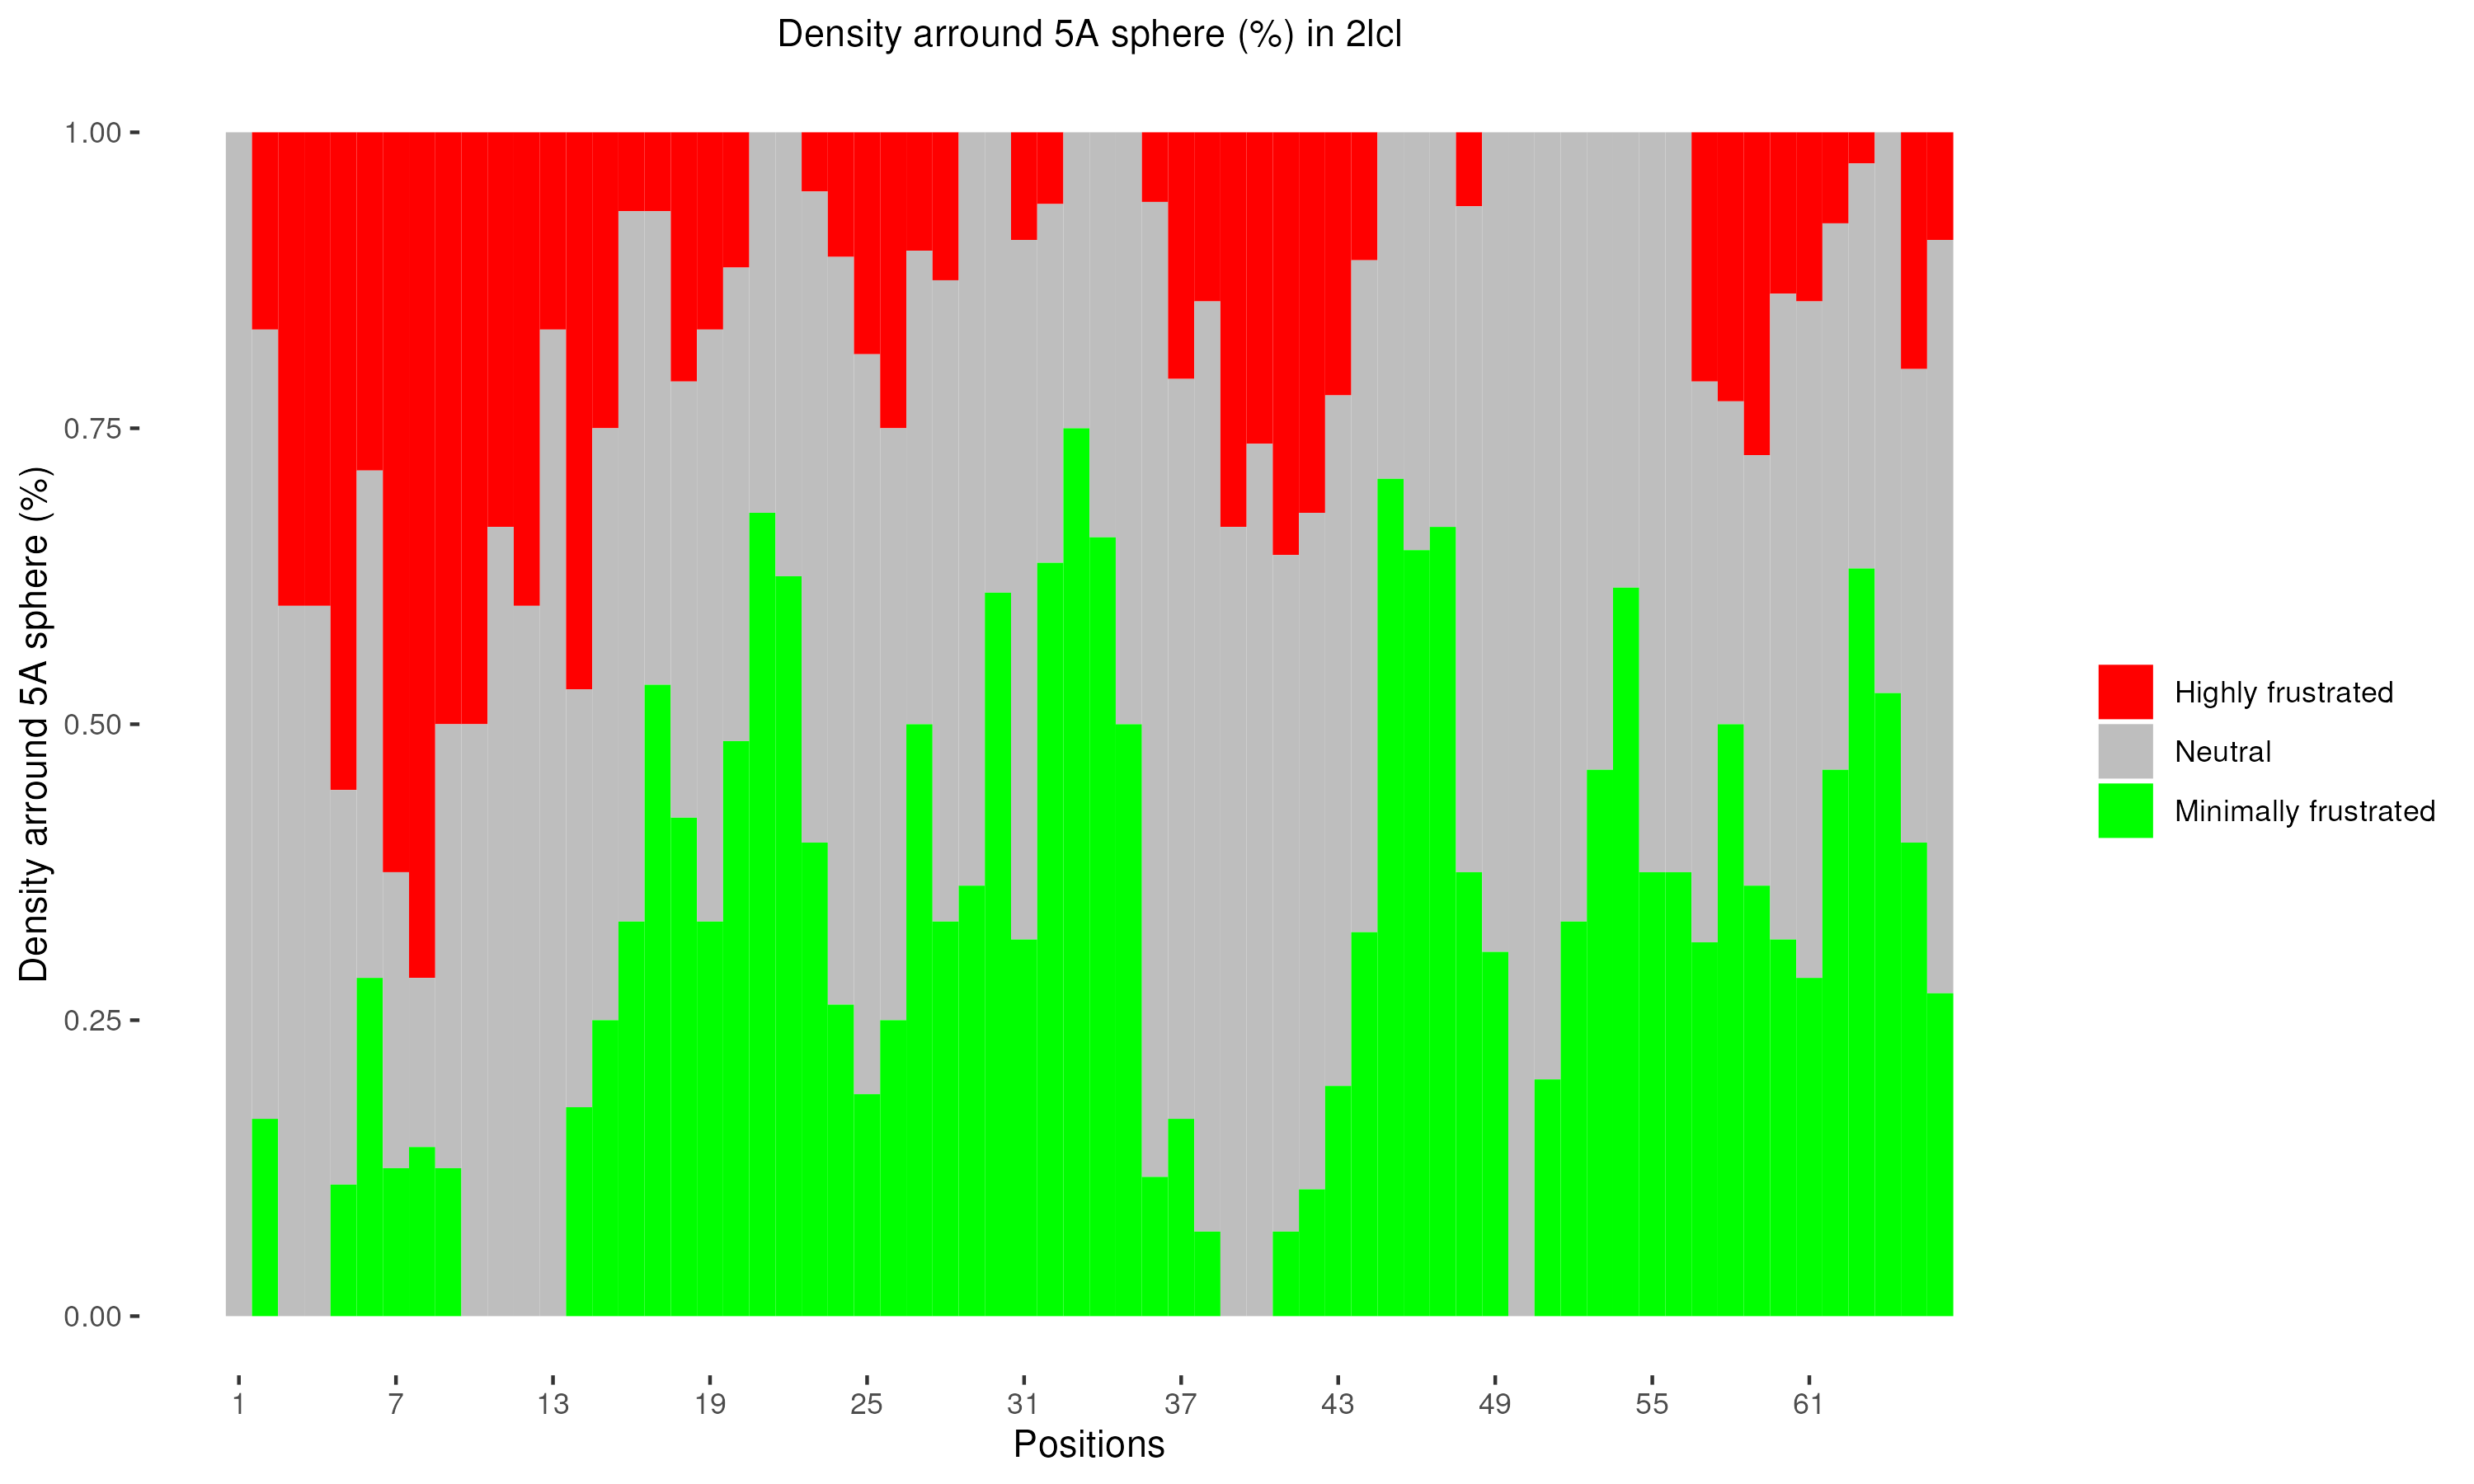

In [ ]:
Image('/content/Results/2lcl.done/Images/2lcl_mutational_5Adens_around.png', width=700, height=400)

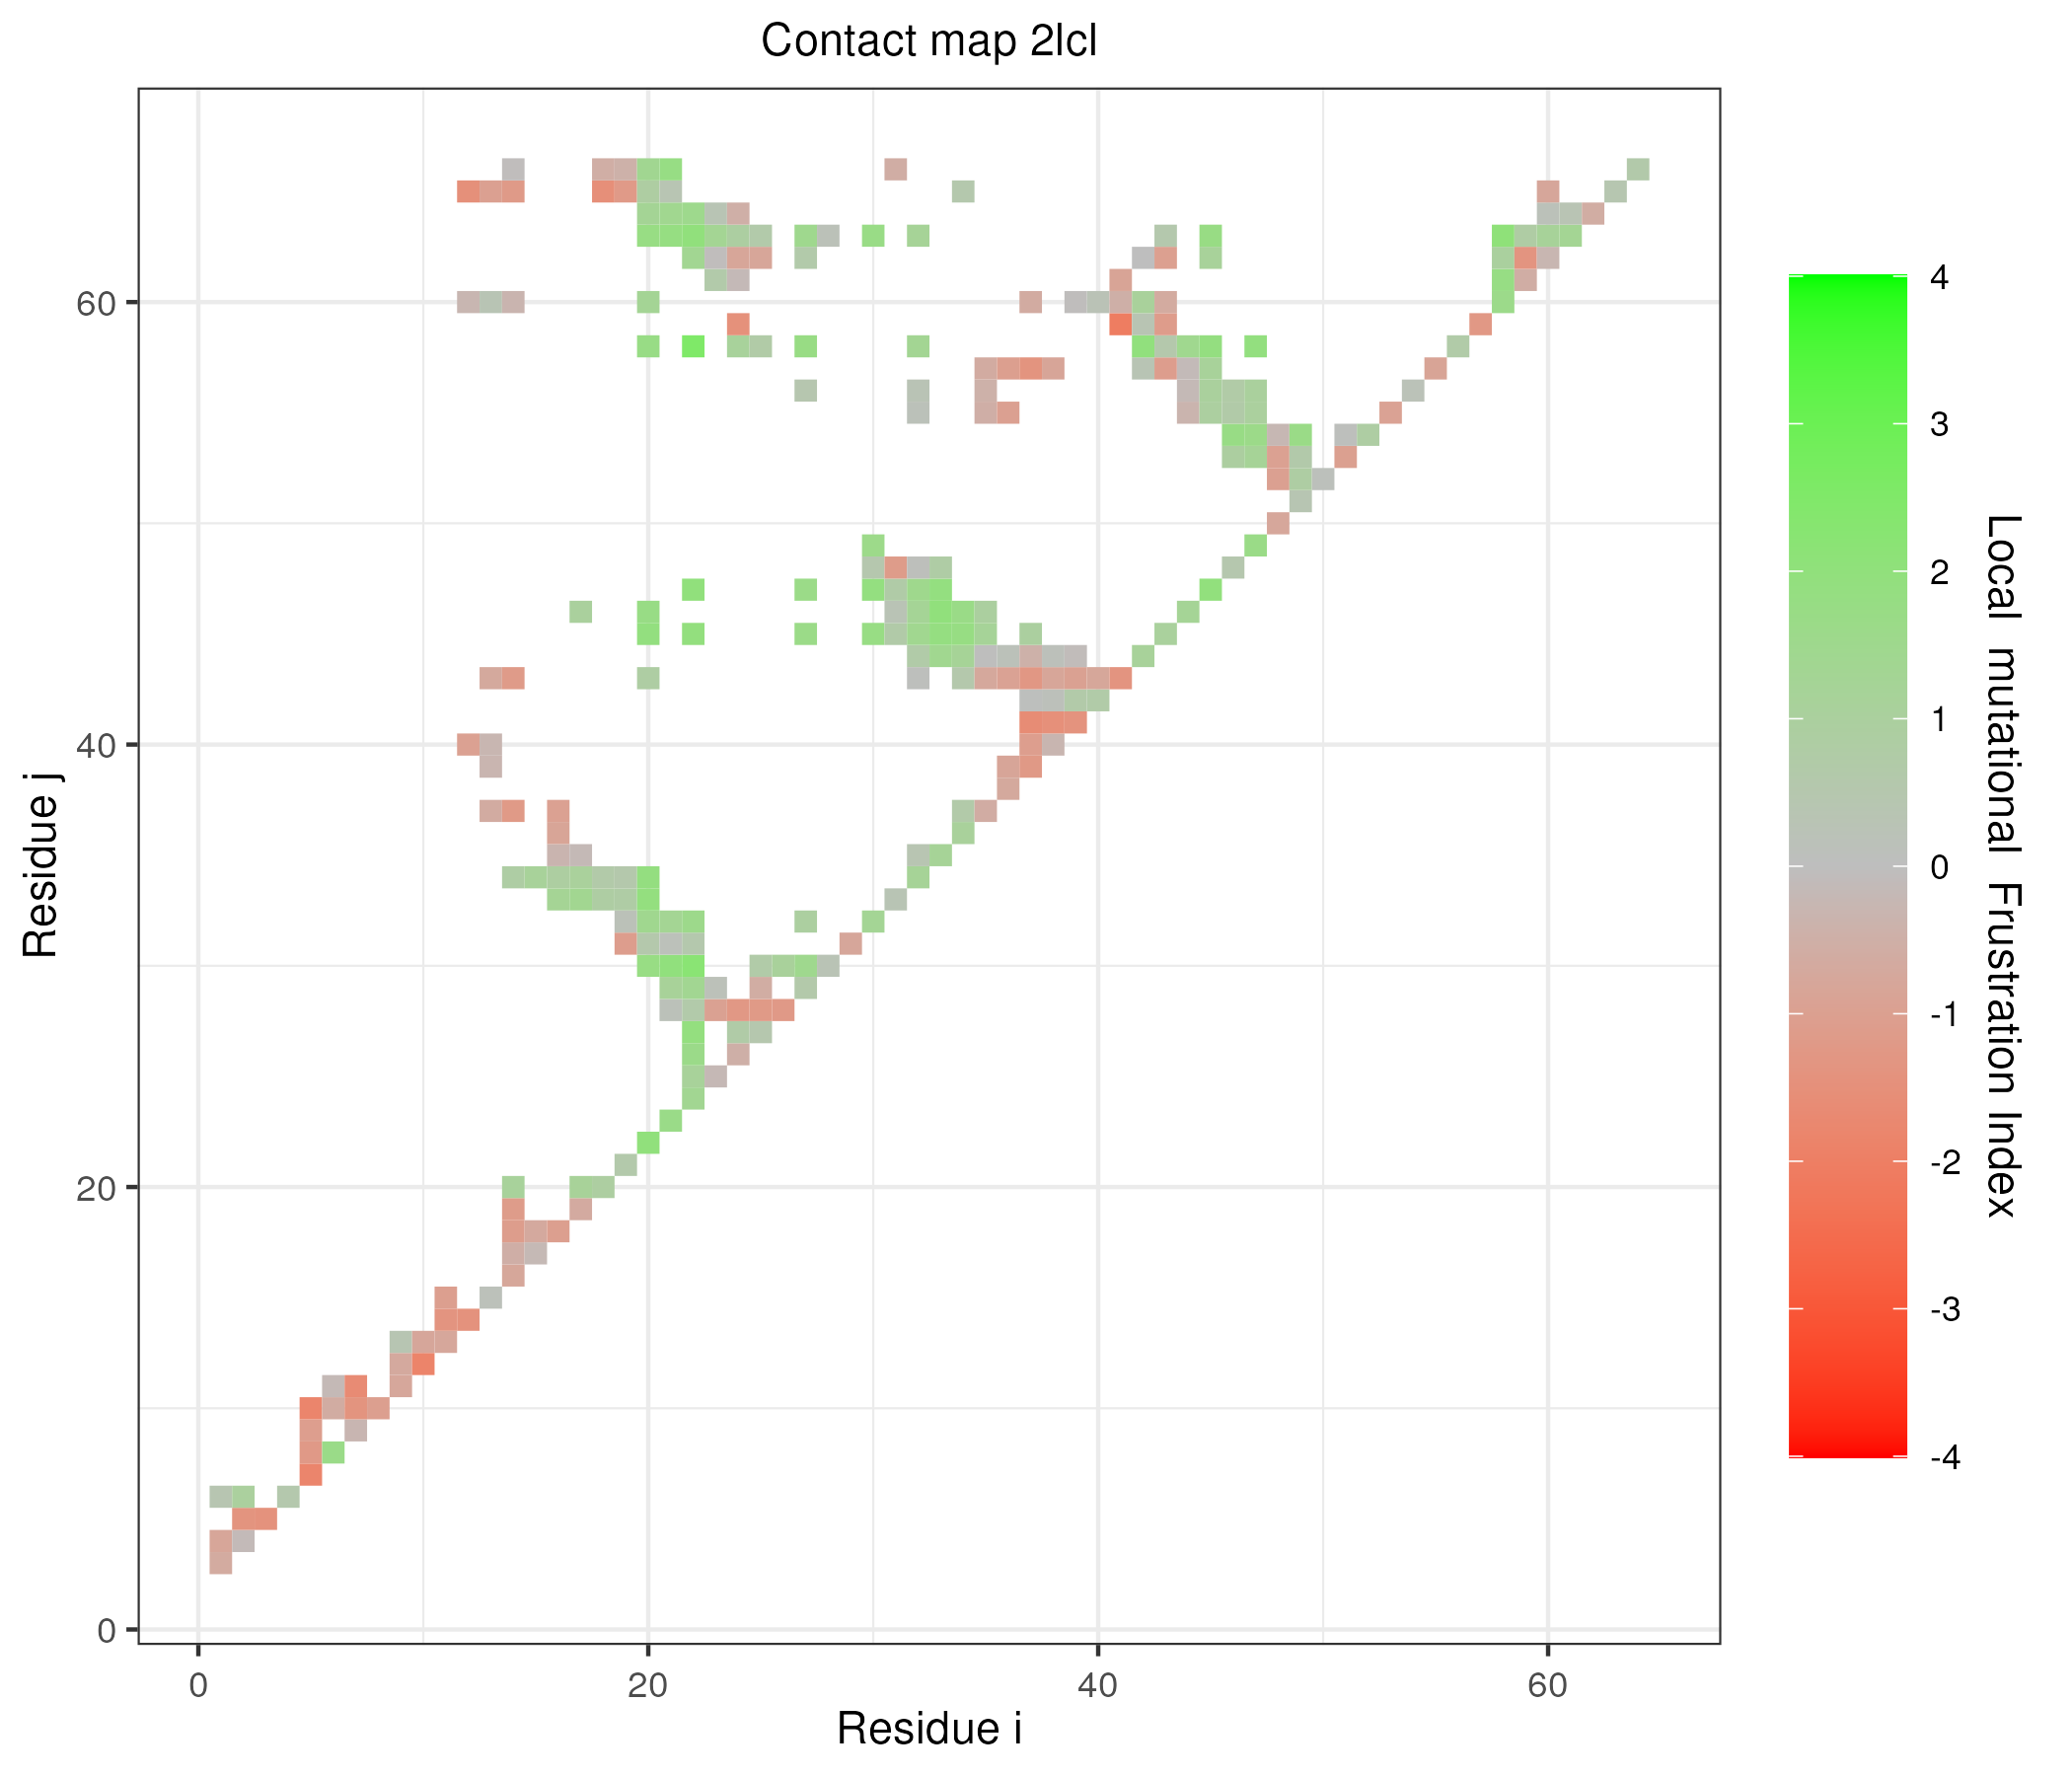

In [ ]:
Image('/content/Results/2lcl.done/Images/2lcl_mutational_map.png', width=500, height=500)

-----------------------------Filtering-----------------------------
-----------------------------Preparing files-----------------------------
-----------------------------Setting options-----------------------------
-----------------------------Calculating-----------------------------
-----------------------------Reorganization-----------------------------
-----------------------------Images-----------------------------
5Adens plot is stored in /content/Results/2lcl_A.done/Images/2lcl_A_mutational.png_5Adens.png
5Adens proportion plot is stored in /content/Results/2lcl_A.done/Images/2lcl_A_mutational_5Adens_around.png
Contact map is stored in /content/Results/2lcl_A.done/Images/2lcl_A_mutational_map.png
-----------------------------Visualizations-----------------------------


****Storage information****
The frustration data was stored in /content/Results/2lcl_A.done/FrustrationData
Graphics are stored in /content/Results/2lcl_A.done/Images
Visualizations are stored in /content/Results

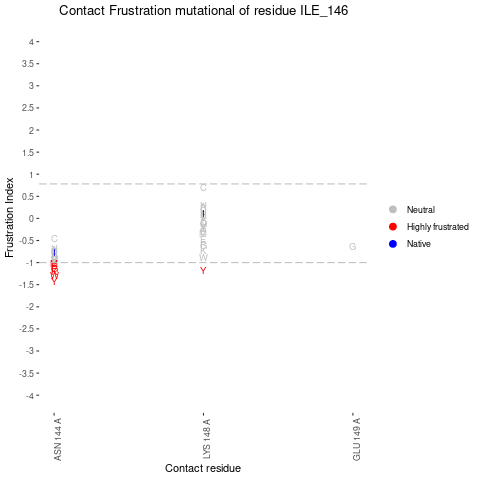

In [ ]:
%%R
library(frustratometeR)

Pdb_conf <- calculate_frustration(PdbFile = '/content/2lcl.pdb', Mode = 'mutational', ResultsDir = "/content/Results/", Chain="A")
Pdb_conf <- mutate_res(Pdb = Pdb_conf, Resno = as.numeric(146), Chain = "A")
plot_mutate_res(Pdb = Pdb_conf, Resno = as.numeric(146), Chain = "A", Save = TRUE )

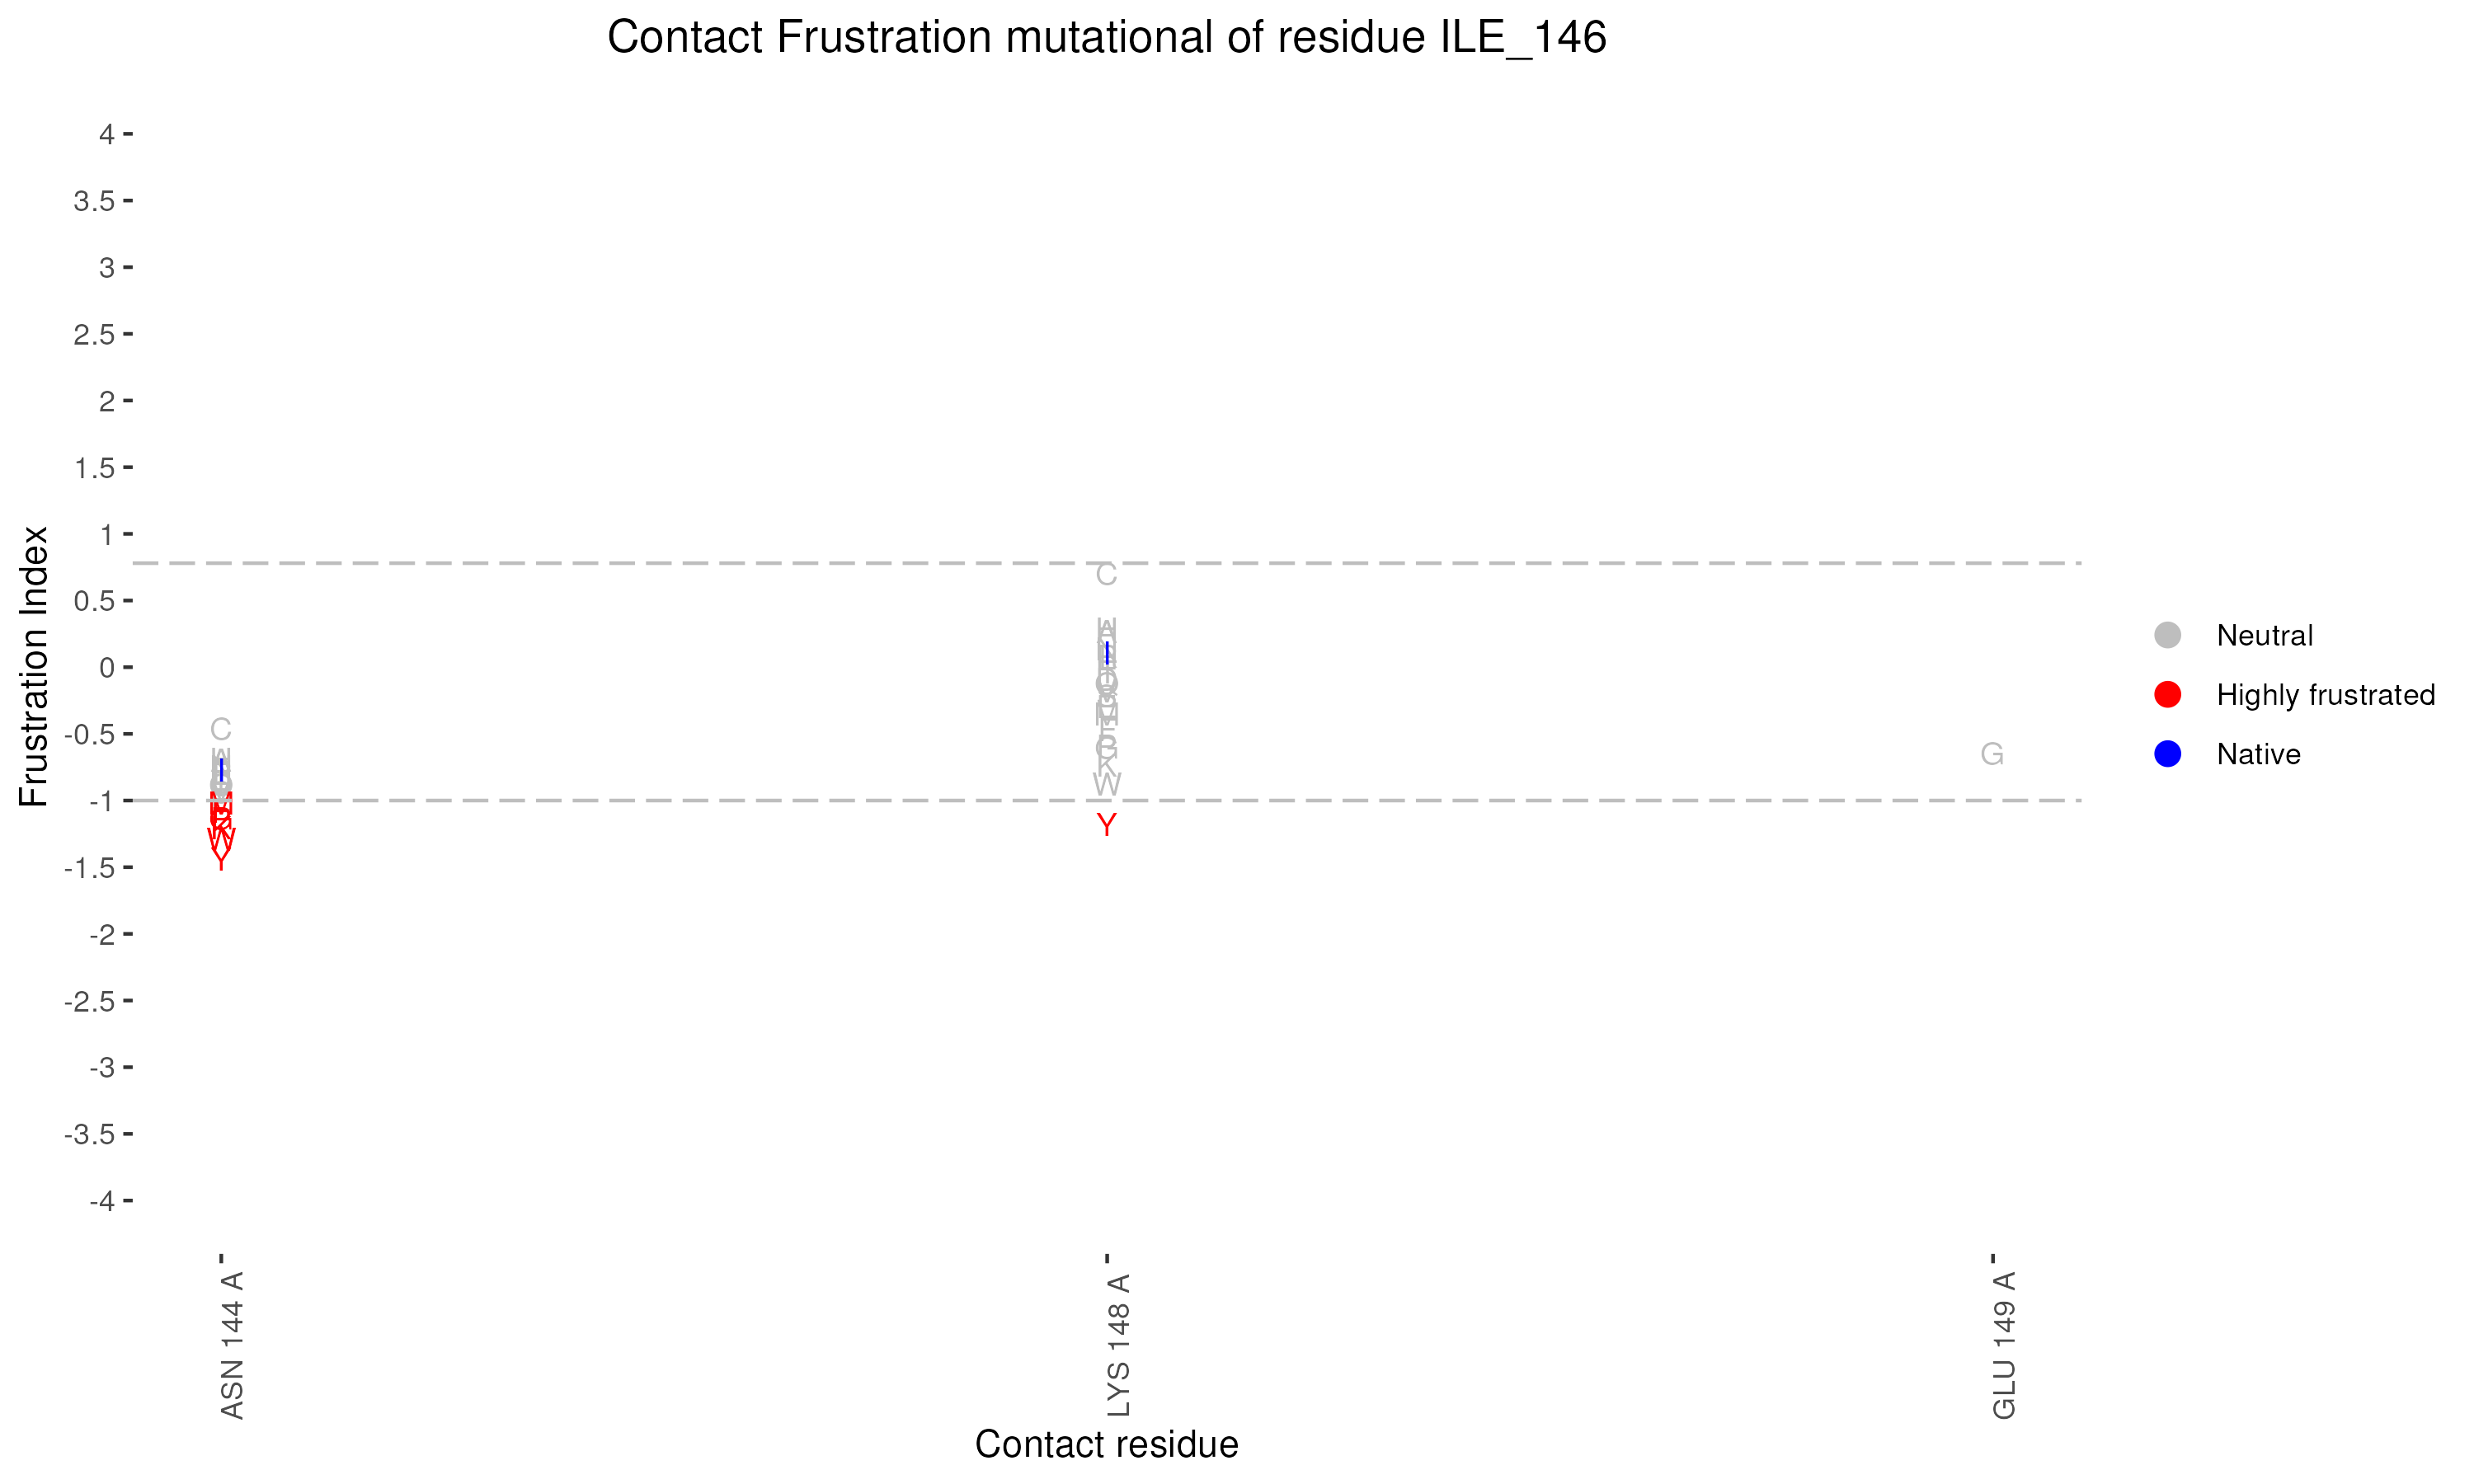

In [ ]:
from IPython.display import Image
Image('/content/Results/2lcl_A.done/MutationsData/Images/mutational_146_threading_A.png')

# Ahora el indice configurational :#

In [ ]:
%%R
library(frustratometeR)

dir_frustration(PdbsDir = "/content/", Mode = "configurational", ResultsDir ="/content/Results/")

-----------------------------Filtering-----------------------------
-----------------------------Preparing files-----------------------------
-----------------------------Setting options-----------------------------
-----------------------------Calculating-----------------------------
-----------------------------Reorganization-----------------------------
-----------------------------Images-----------------------------
5Adens plot is stored in /content/Results/2lcl.done/Images/2lcl_configurational.png_5Adens.png
5Adens proportion plot is stored in /content/Results/2lcl.done/Images/2lcl_configurational_5Adens_around.png
Contact map is stored in /content/Results/2lcl.done/Images/2lcl_configurational_map.png
-----------------------------Visualizations-----------------------------


****Storage information****
The frustration data was stored in /content/Results/2lcl.done/FrustrationData
Graphics are stored in /content/Results/2lcl.done/Images
Visualizations are stored in /content/Results/

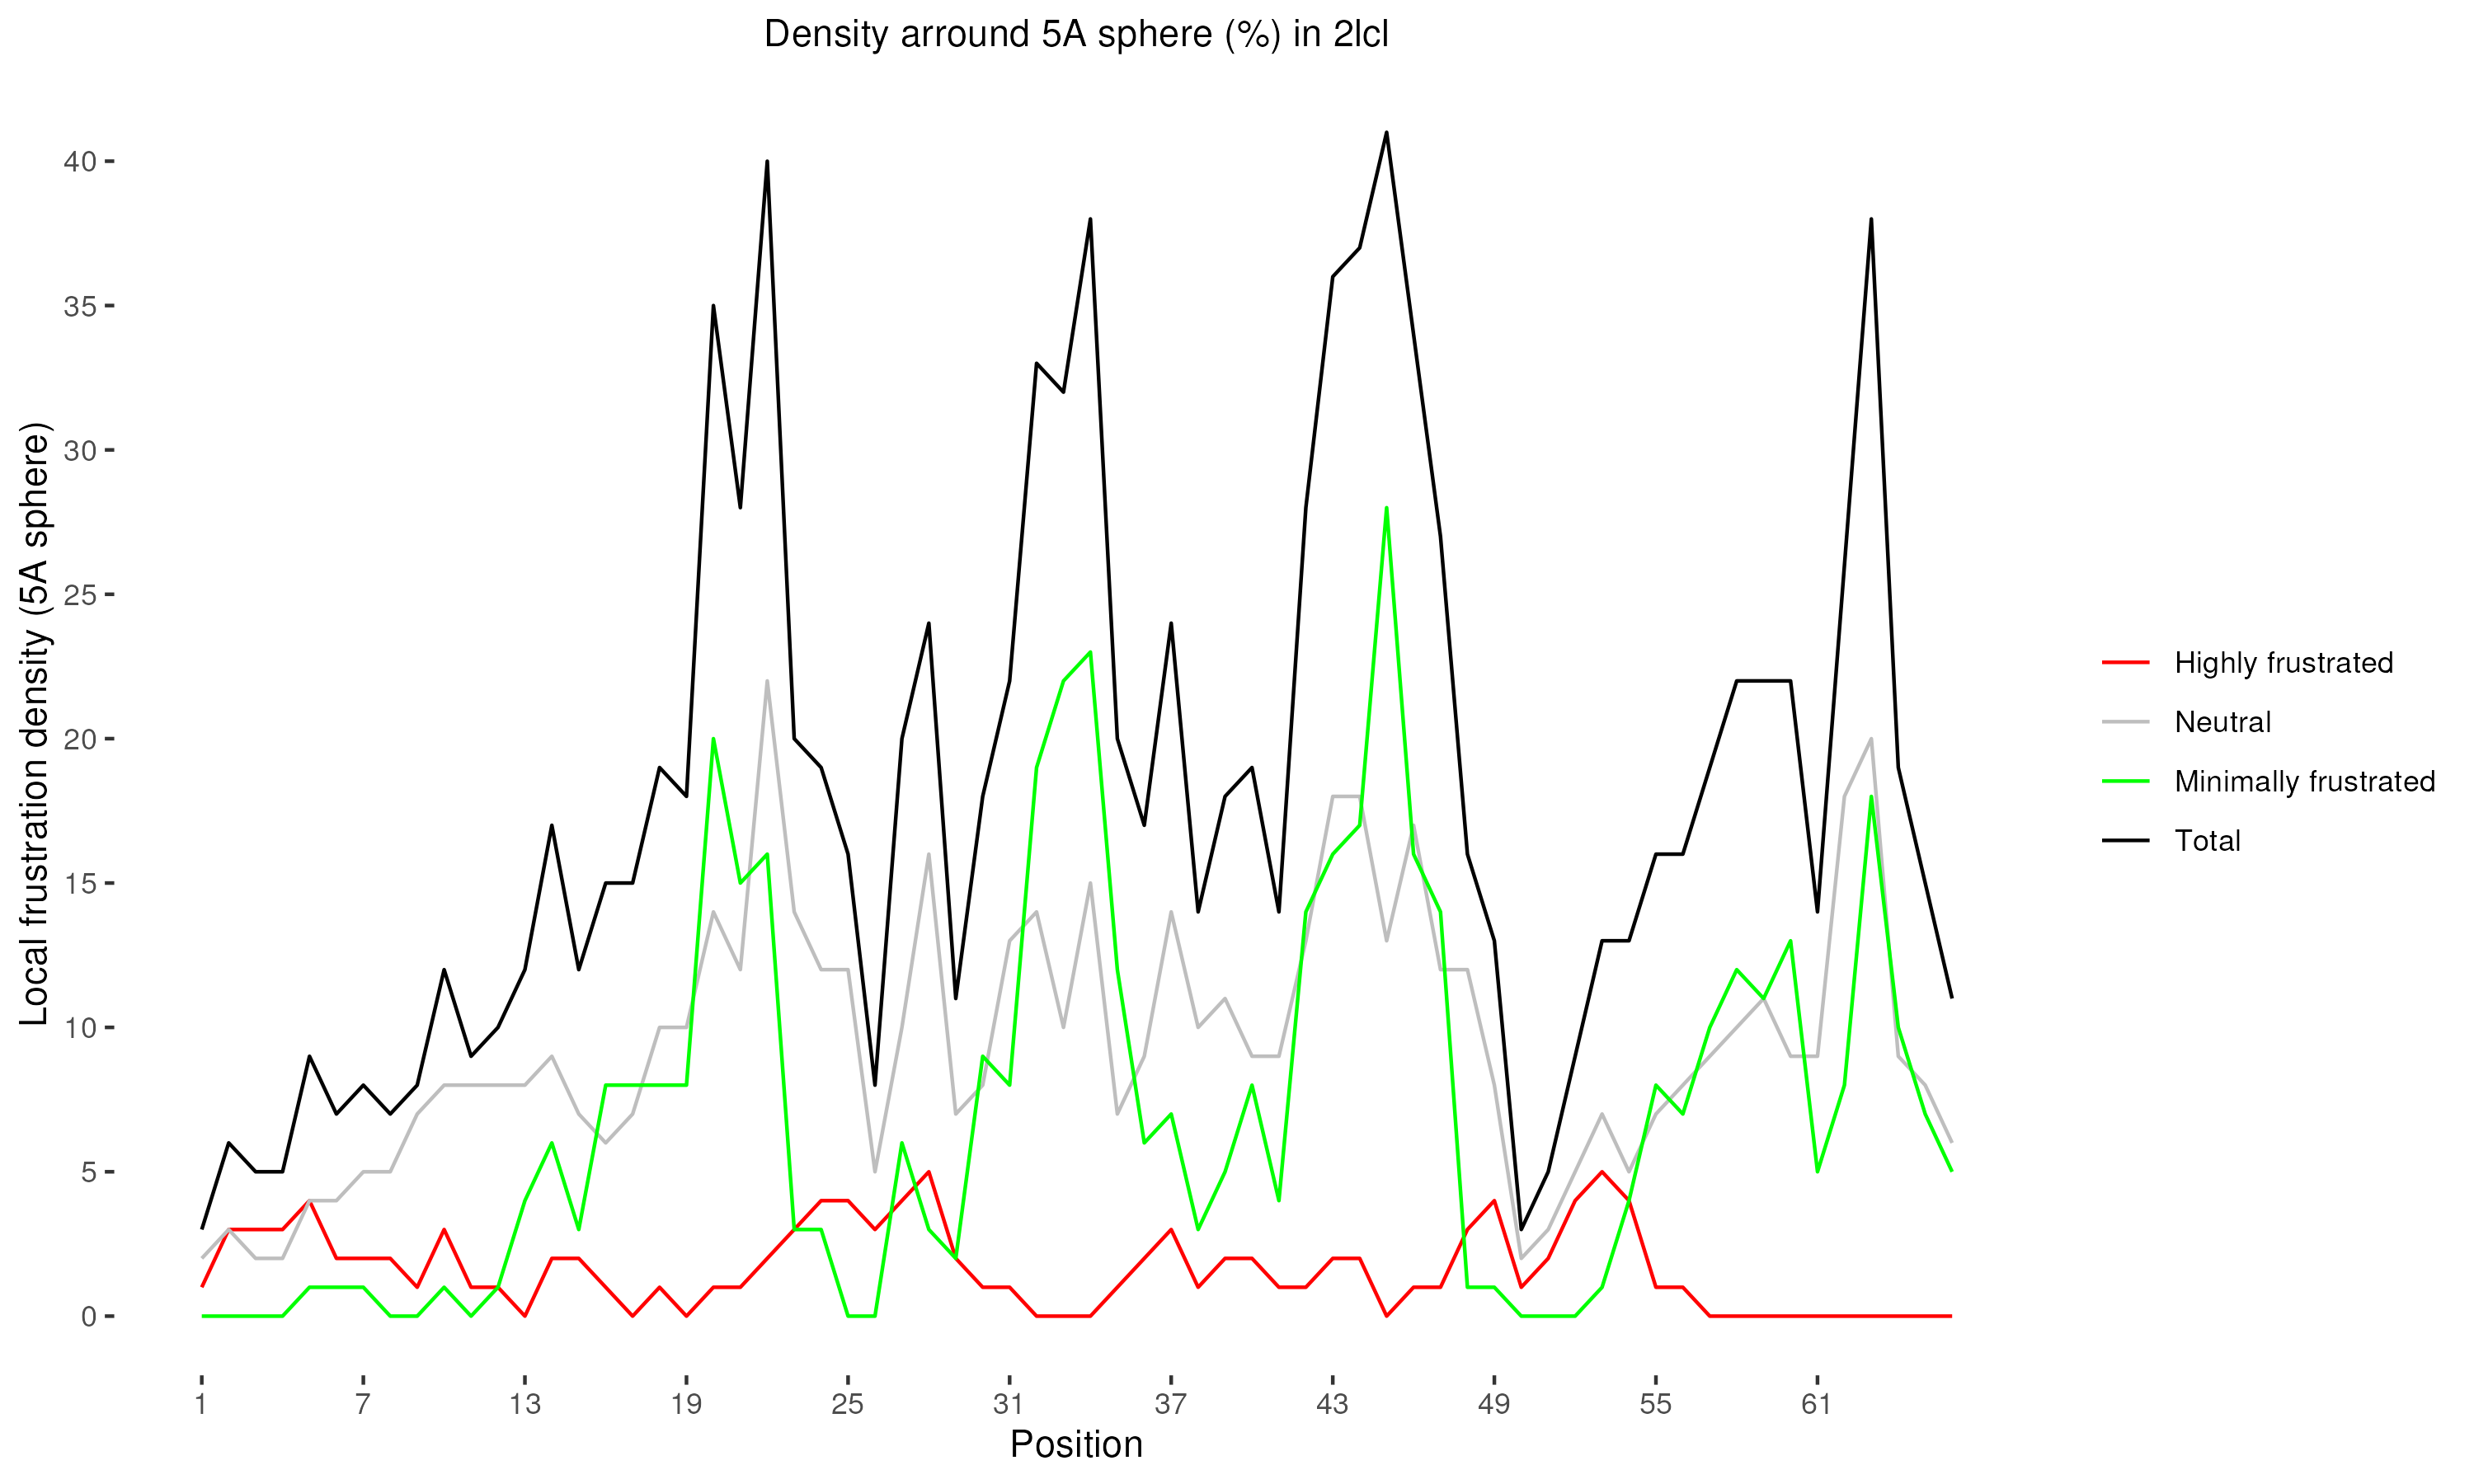

In [ ]:
Image('/content/Results/2lcl.done/Images/2lcl_configurational.png_5Adens.png', width=700, height=400)

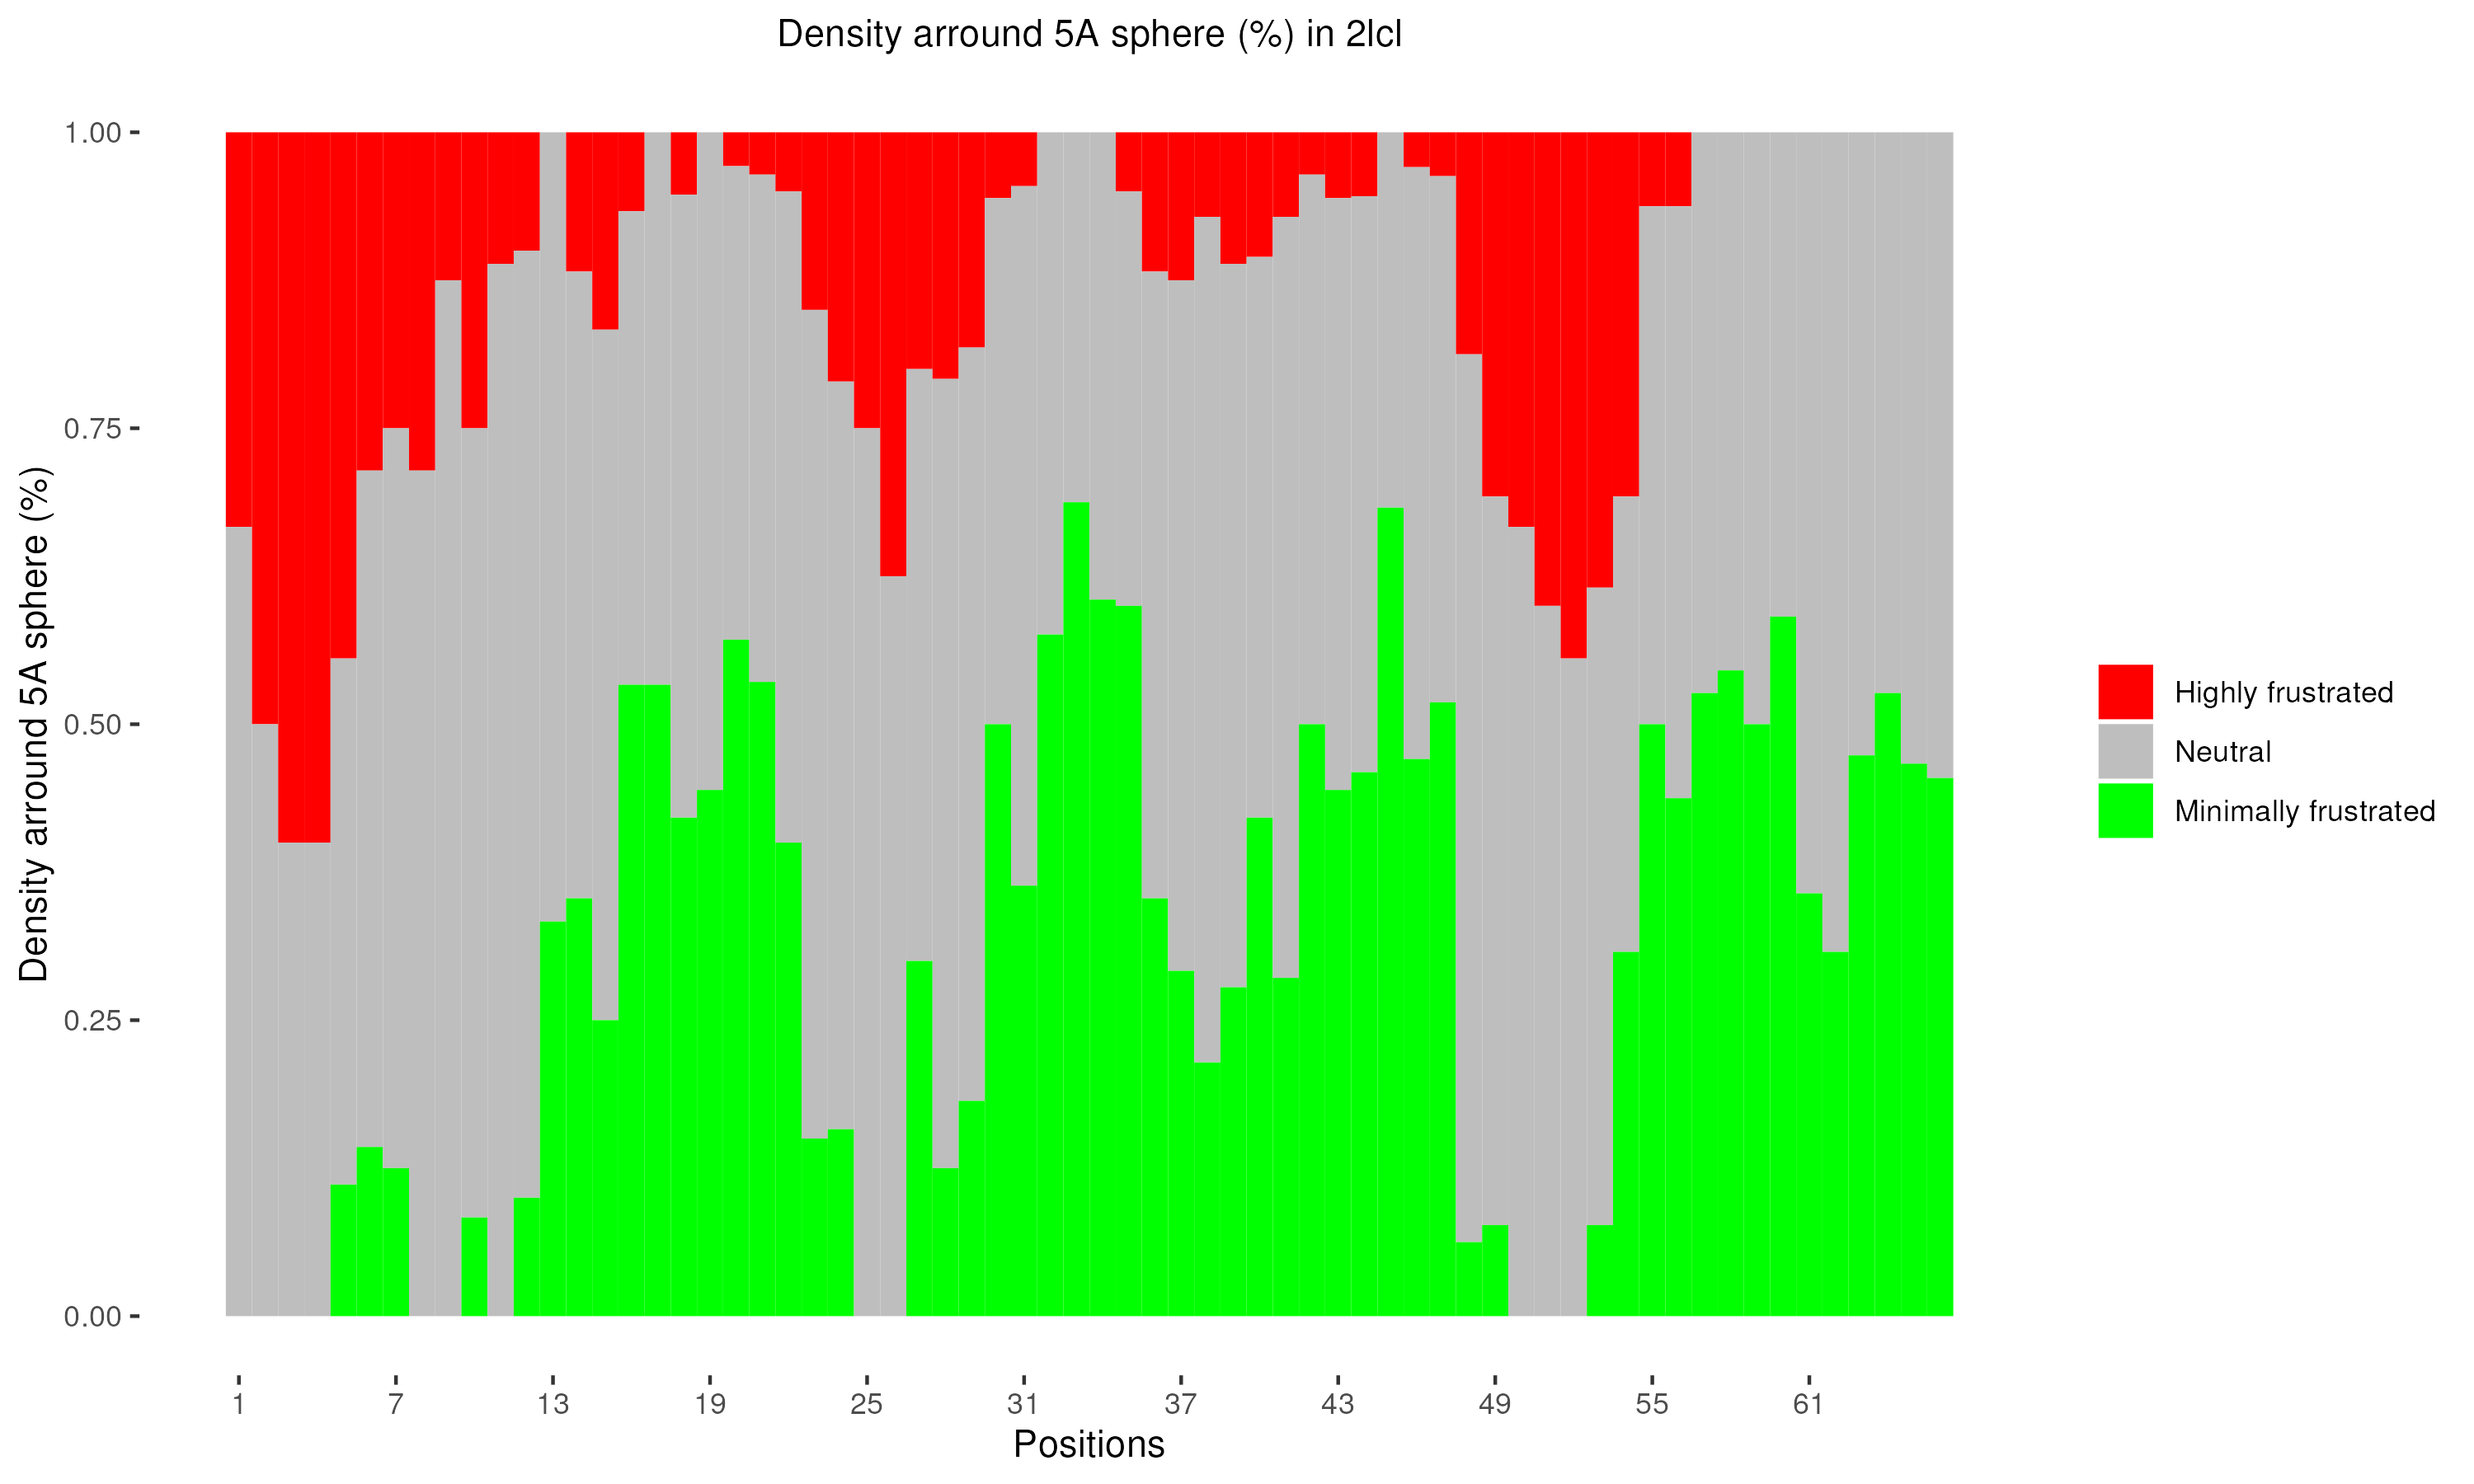

In [ ]:
Image('/content/Results/2lcl.done/Images/2lcl_configurational_5Adens_around.png', width=700, height=400)

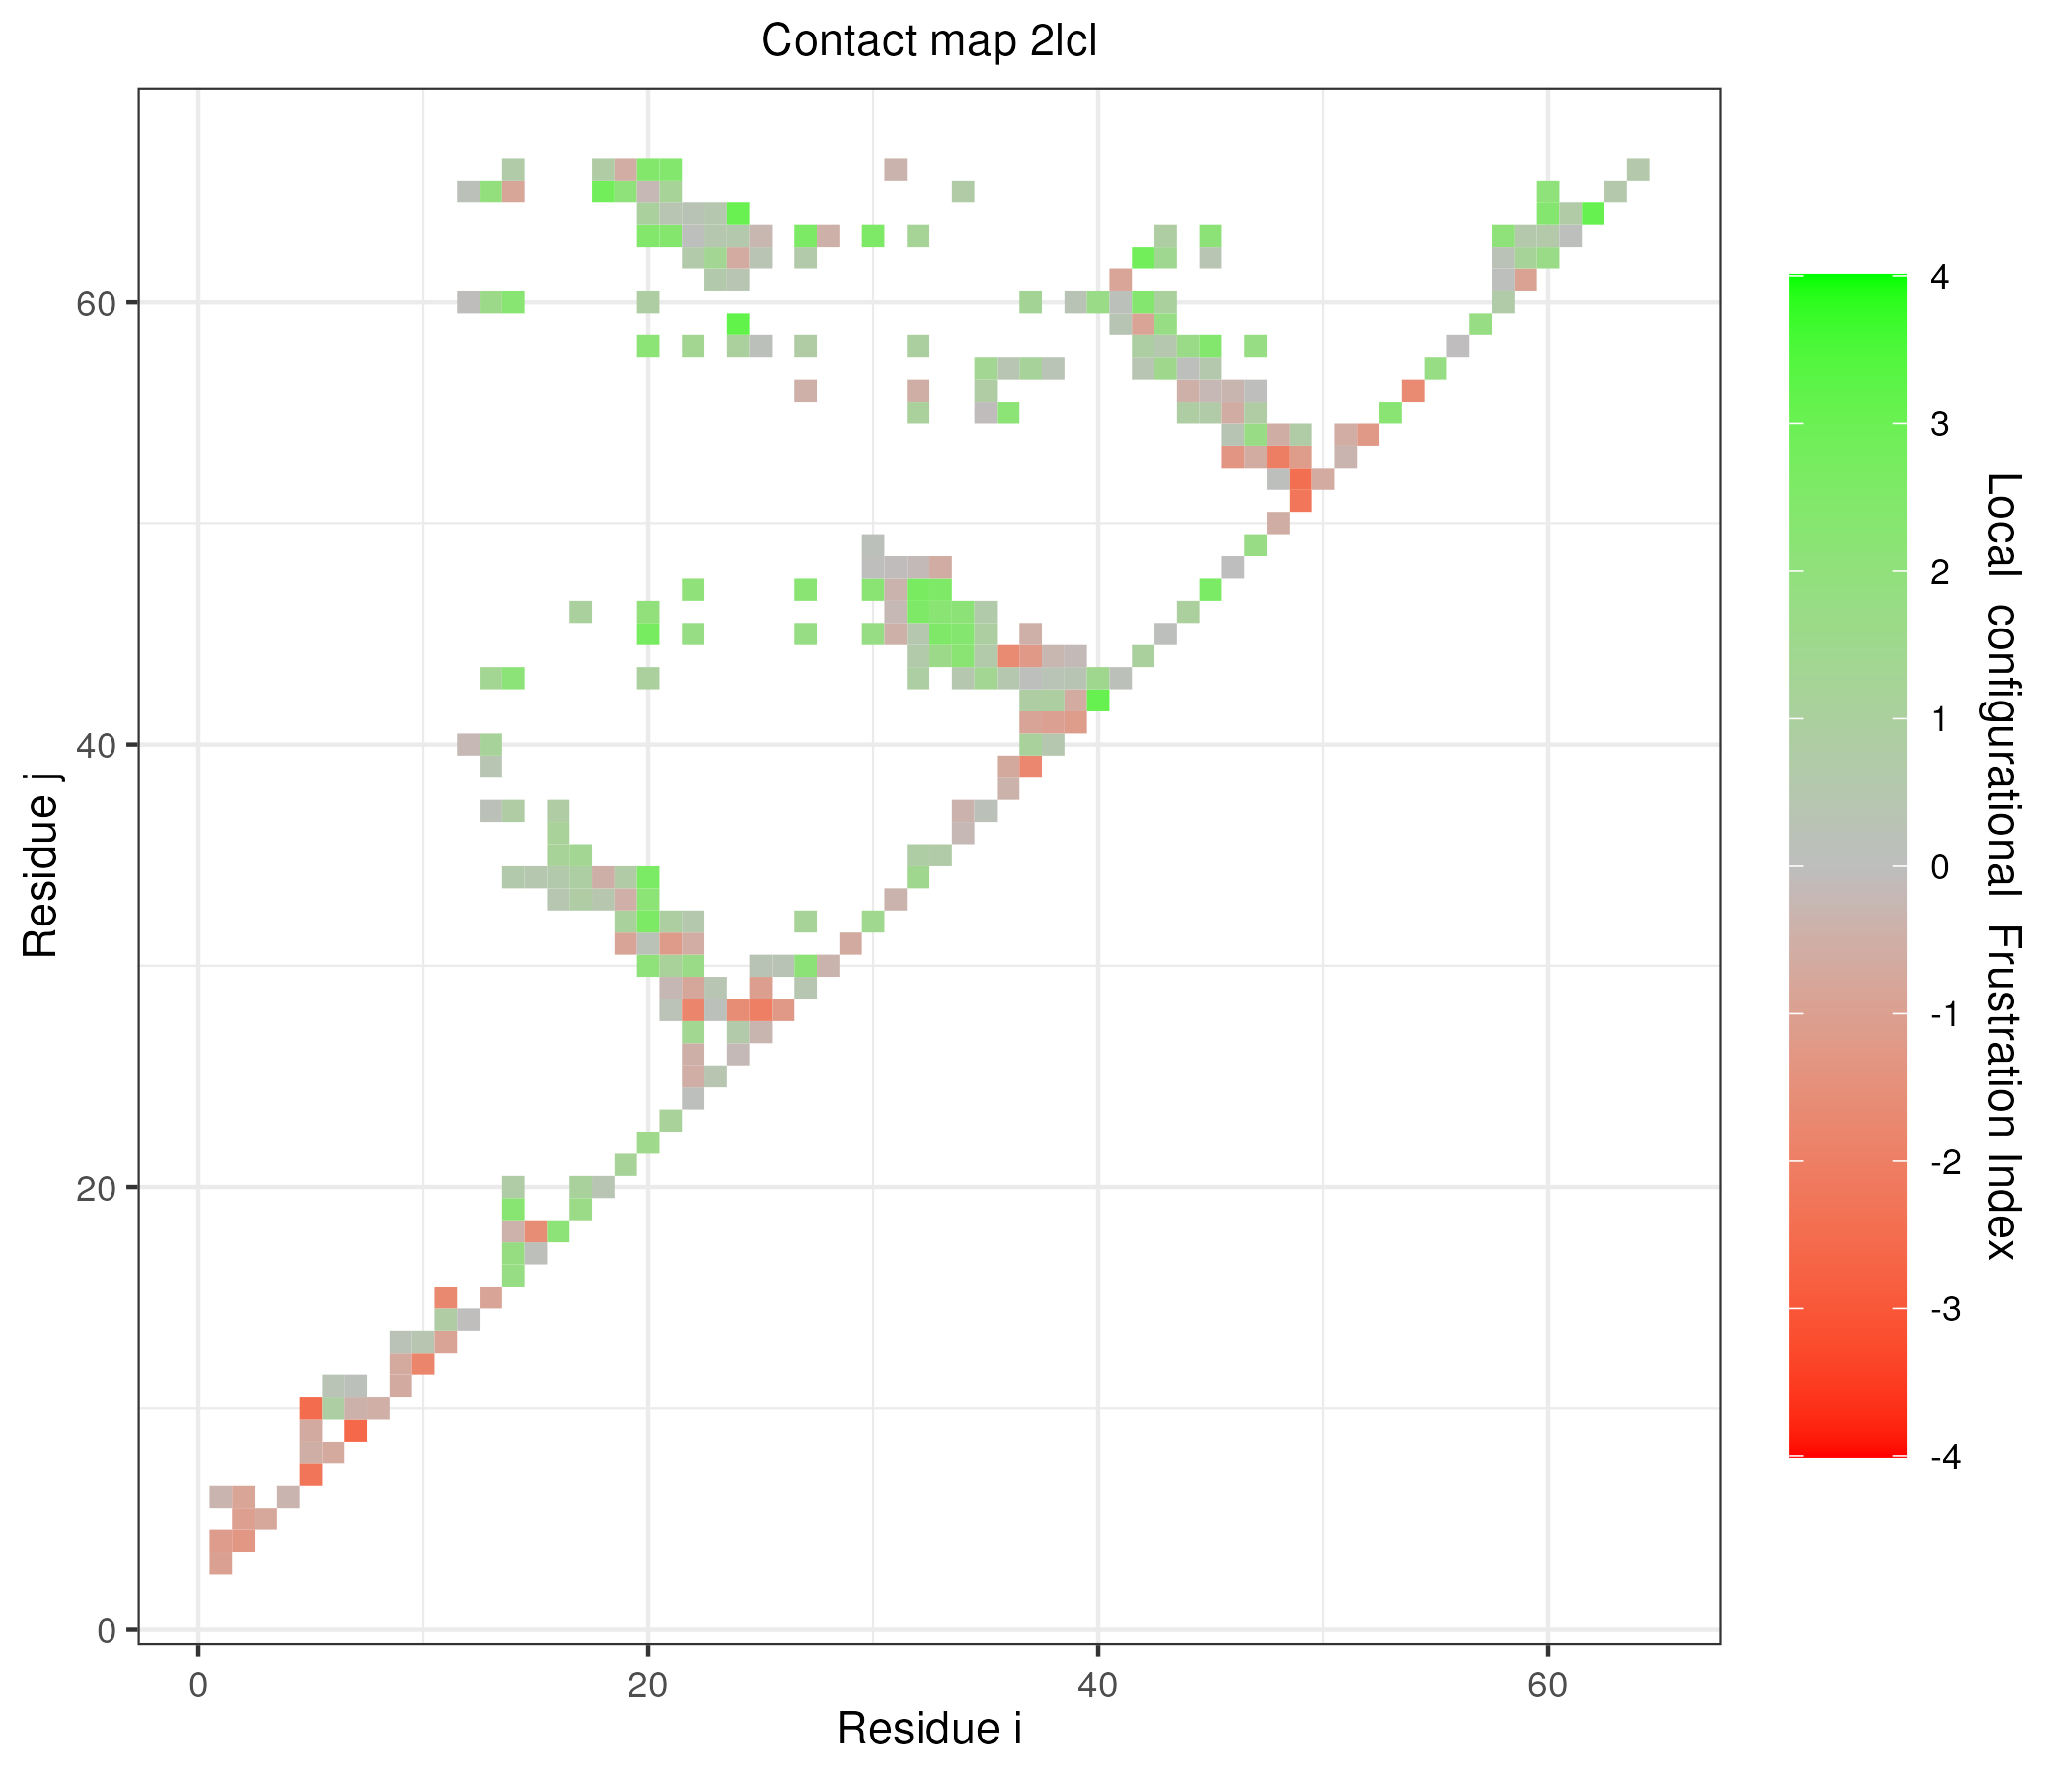

In [ ]:
Image('/content/Results/2lcl.done/Images/2lcl_configurational_map.png', width=500, height=500)

# Part 2 : First approach to Dynamic_frstration() function:

 ## Frustration across NMR ensemble of RfaH using single residue

Now we will do the analysis for the complete set of structures obtained from PDB.

## 1) To do the analysis we need to make a prior splitting the ensemble, and we we do this by using the following Bio-python script.

 ## 2) First we will make a New directory named FoxP_NMR, inside the content working directory.

In [ ]:
#!mkdir /content/Beta_CTD

In [ ]:
#Toma un ensamble de NMR de la PDB y lo particiona y enumara en varios frames del 1 al 20
from Bio import PDB
import os

pdb_parser = PDB.PDBParser(QUIET=True)
structure = pdb_parser.get_structure("modelo", "/content/2lcl.pdb")
for model_num, model in enumerate(structure):
    for submodel_num, submodel in enumerate(model):
        io = PDB.PDBIO()
        io.set_structure(submodel)
        output_file = f"/content/2lcl{model_num + 1}.pdb"
        io.save(output_file)


### El siguiente script obtiene informacion deldirectorio para generar los objetos o vectores a recorrer en analisis posteriores.

In [ ]:
#### Generating the List las listas ####
import os
# Ruta de la carpeta que deseas explorar
ruta_carpeta = '/content/'
# Obtener una lista de los nombres de archivo en la carpeta
nombres_archivos = os.listdir(ruta_carpeta)
# Imprime la ubicación actual
print(os.getcwd())
# Imprimir la lista de nombres de archivo
print(nombres_archivos)

/tmp/RtmpQnF2v5
['.config', '2lcl6.pdb', '2lcl8.pdb', '2lcl14.pdb', '2lcl13.pdb', '2lcl4.pdb', 'Results', '2lcl3.pdb', '2lcl2.pdb', '2lcl9.pdb', '2lcl19.pdb', '2lcl7.pdb', '2lcl12.pdb', '2lcl16.pdb', '2LCL_A.fasta', '2lcl.pdb', '2lcl20.pdb', '2lcl11.pdb', 'modeller_9.25-1_amd64.deb', '2lcl5.pdb', '2lcl17.pdb', '2lcl15.pdb', '2lcl18.pdb', '2lcl1.pdb', '2lcl10.pdb', 'sample_data']


# Visualize like a trajectory

In [ ]:
#!touch /content/traj.pdb
#!rm /content/traj.pdb
#!for f in $(ls -1v /content/Dynamics/*pdb); do (cat "${f}"; echo) >> /content/traj.pdb; done

#@title ###Visualize trajectory
#define number of frames
import py3Dmol

view = py3Dmol.view()

view.addModelsAsFrames(open('/content/2lcl.pdb', 'r').read(),'pdb')

view.setStyle({'cartoon': {'color':'blue'}})

BB = ['C','O','N']
view.addStyle({'and':[{'resn':["GLY","PRO"],'invert':True},{'atom':BB,'invert':True}]},
                        {'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
view.addStyle({'and':[{'resn':"GLY"},{'atom':'CA'}]},
                        {'sphere':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
view.addStyle({'and':[{'resn':"PRO"},{'atom':['C','O'],'invert':True}]},
                        {'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})

view.zoomTo()
view.animate({'loop': "forward"})
view.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
#Loading the R extension interactively
%reload_ext rpy2.ipython

*italicized text*



Let's get started **frustrating a Beta CTD RfaH ensemble** (PdbID 2lcl Chain A). So the first y create the working and results directory.

##The full path of the directory where the structures are located (PdbsDir), the order in which they will be analysed (OrderList, optional) and the desired frustration index (Mode) have to be passed as parameters. Here we will explore the last index "singleresidue"

In [ ]:
%%R
library(reticulate)
library(frustratometeR)

PdbsDir <- "/content/"      # Donde estan los PDBs separados guardados


ResultsDir <- "/content/Results/"   # Donde se iran los resultados

# Crear una lista vacía para almacenar los nombres de archivo
OrderList <- c()

# Iterar sobre los números del 1 al 20
for (i in 1:20) {
    # Generar el nombre de archivo con el prefijo "2kiu"
    file_name <- paste("2lcl", i, ".pdb", sep = "")
    # Agregar el nombre de archivo a la lista
    OrderList <- c(OrderList, file_name)
}

# Llamar a la función dynamic_frustration con OrderList actualizado para generar el objeto dinamico
Dynamic_sing <- dynamic_frustration(PdbsDir = PdbsDir, ResultsDir = ResultsDir, OrderList = OrderList,
                                    GIFs = FALSE, Mode = "singleresidue")


-----------------------------Object Dynamic Frustration-----------------------------
-----------------------------Calculating Dynamic Frustration-----------------------------
-----------------------------Filtering-----------------------------
-----------------------------Preparing files-----------------------------
-----------------------------Setting options-----------------------------
-----------------------------Calculating-----------------------------
-----------------------------Reorganization-----------------------------


****Storage information****
The frustration data was stored in /content/Results/2lcl1.done/FrustrationData
-----------------------------Filtering-----------------------------
-----------------------------Preparing files-----------------------------
-----------------------------Setting options-----------------------------
-----------------------------Calculating-----------------------------
-----------------------------Reorganization----------------------------


## We will use the dynamic_res() function to analyse frustration over specific residue N° 39 in the NMR as if it were a MD trajectory.


El archivo que genera por frame es el 2kiu_1.pdb_singleresidue ##
que esta en el directorio 2kiu_1_done ##

In [ ]:
%%R
library(frustratometeR)

# Analyzing residue Resno
Dynamic_sing <- dynamic_res(Dynamic = Dynamic_sing, Resno = 111, Chain = "A")
Dynamic_sing <- dynamic_res(Dynamic = Dynamic_sing, Resno = 130, Chain = "A")
Dynamic_sing <- dynamic_res(Dynamic = Dynamic_sing, Resno = 138, Chain = "A")
Dynamic_sing <- dynamic_res(Dynamic = Dynamic_sing, Resno = 146, Chain = "A")

-----------------------------Getting frustrated data-----------------------------


****Storage information****
The frustration of the residue is stored in /content/Results/Dynamic_plots_res_111_A/singleresidue_Res_111_A

To make the graph, the Local Polynomial Regression Model was adjusted with Loesspan = 0.05. To use custom parameters, run previously detect_dynamic_clusters().

Dynamic_res plot is stored in /content/Results/Dynamic_plots_res_111_A/dynamic_IndexFrustration_singleresidue_Res111.png
-----------------------------Getting frustrated data-----------------------------


****Storage information****
The frustration of the residue is stored in /content/Results/Dynamic_plots_res_130_A/singleresidue_Res_130_A

To make the graph, the Local Polynomial Regression Model was adjusted with Loesspan = 0.05. To use custom parameters, run previously detect_dynamic_clusters().

Dynamic_res plot is stored in /content/Results/Dynamic_plots_res_130_A/dynamic_IndexFrustration_singleresidue_Res

In [ ]:
%%R
library(frustratometeR)
frustra_movie(Dynamic = Dynamic_sing)

Script that loads visualizations is stored in /content/Results/FrustraMovie/representations_singleresidue.pml
Script that generates movie is stored in /content/Results/FrustraMovie/GenerateMovie_singleresidue.pml


## The follow script caculate the energetig frustration for specific or single residue along to the ensemble , so we can extend the aplicability to Molecuar dynamics changes in the local frustration.

To make the graph, the Local Polynomial Regression Model was adjusted with Loesspan = 0.05. To use custom parameters, run previously detect_dynamic_clusters().



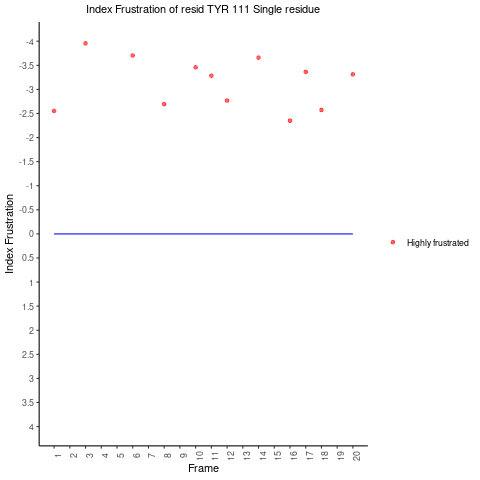

In [ ]:
%%R
library(frustratometeR)
# Visualization
plot_res_dynamics(Dynamic = Dynamic_sing, Resno = 111, Chain = "A")

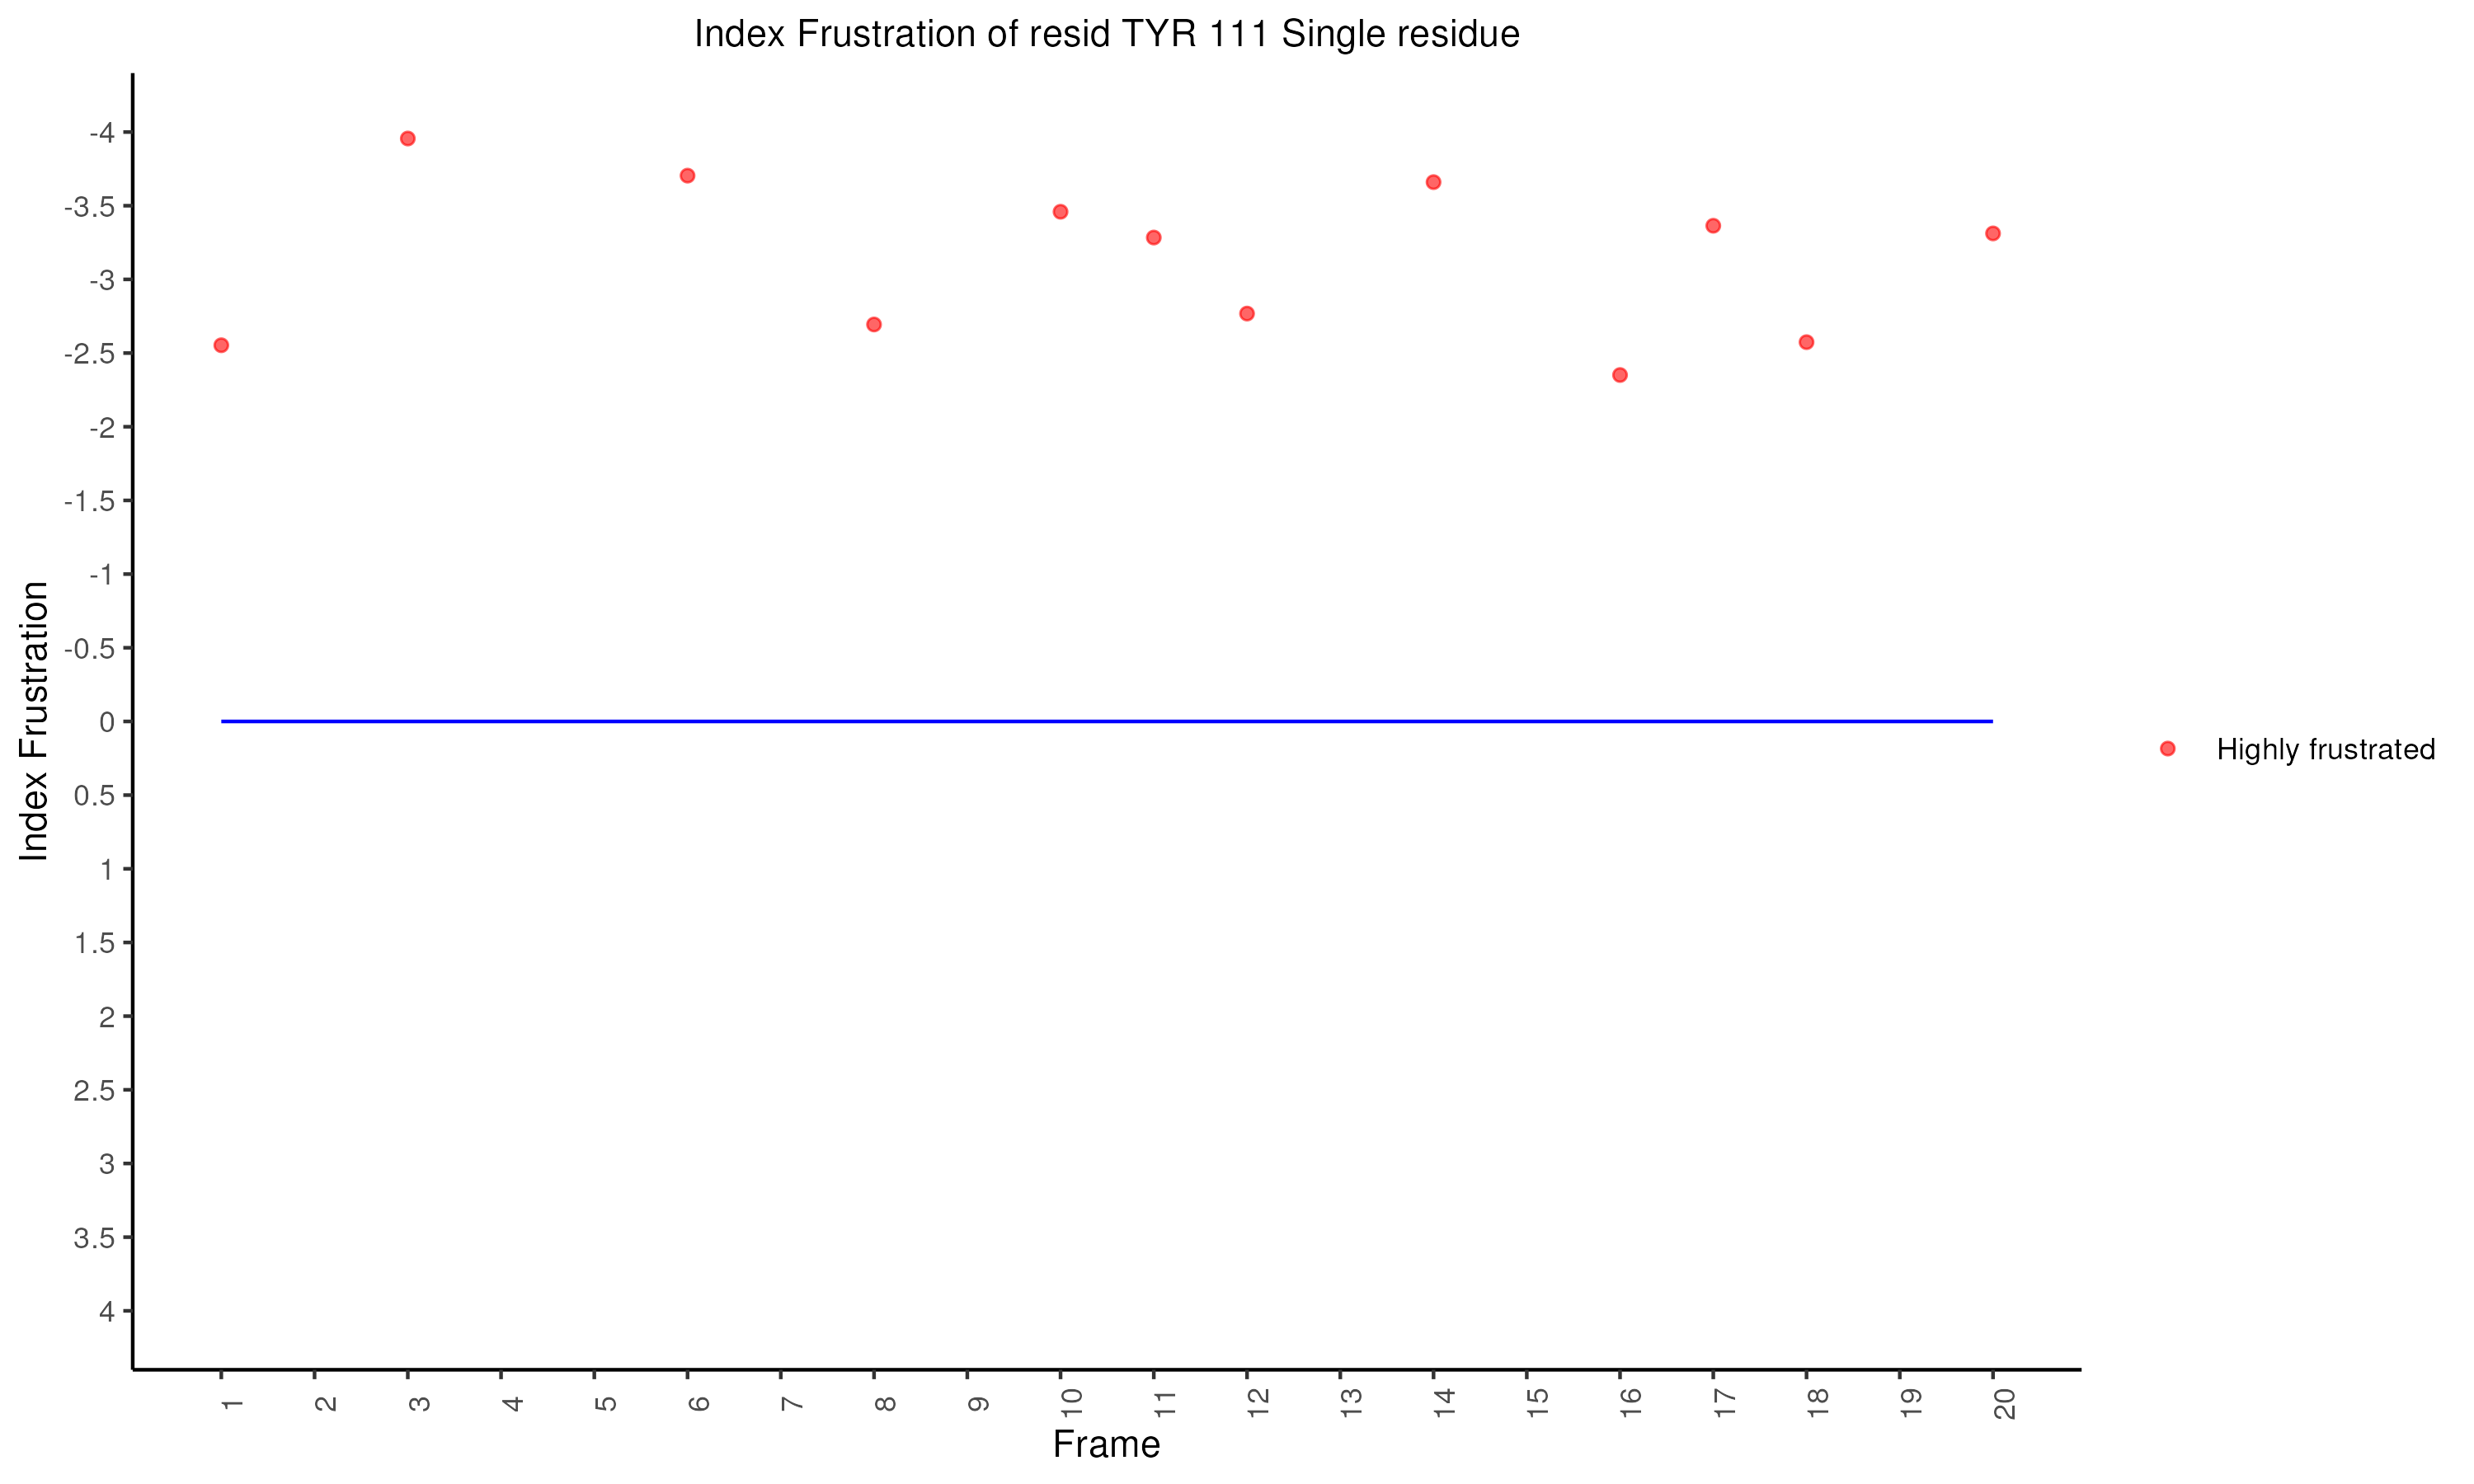

In [ ]:
from IPython.display import Image
Image('/content/Results/Dynamic_plots_res_111_A/dynamic_IndexFrustration_singleresidue_Res111.png')

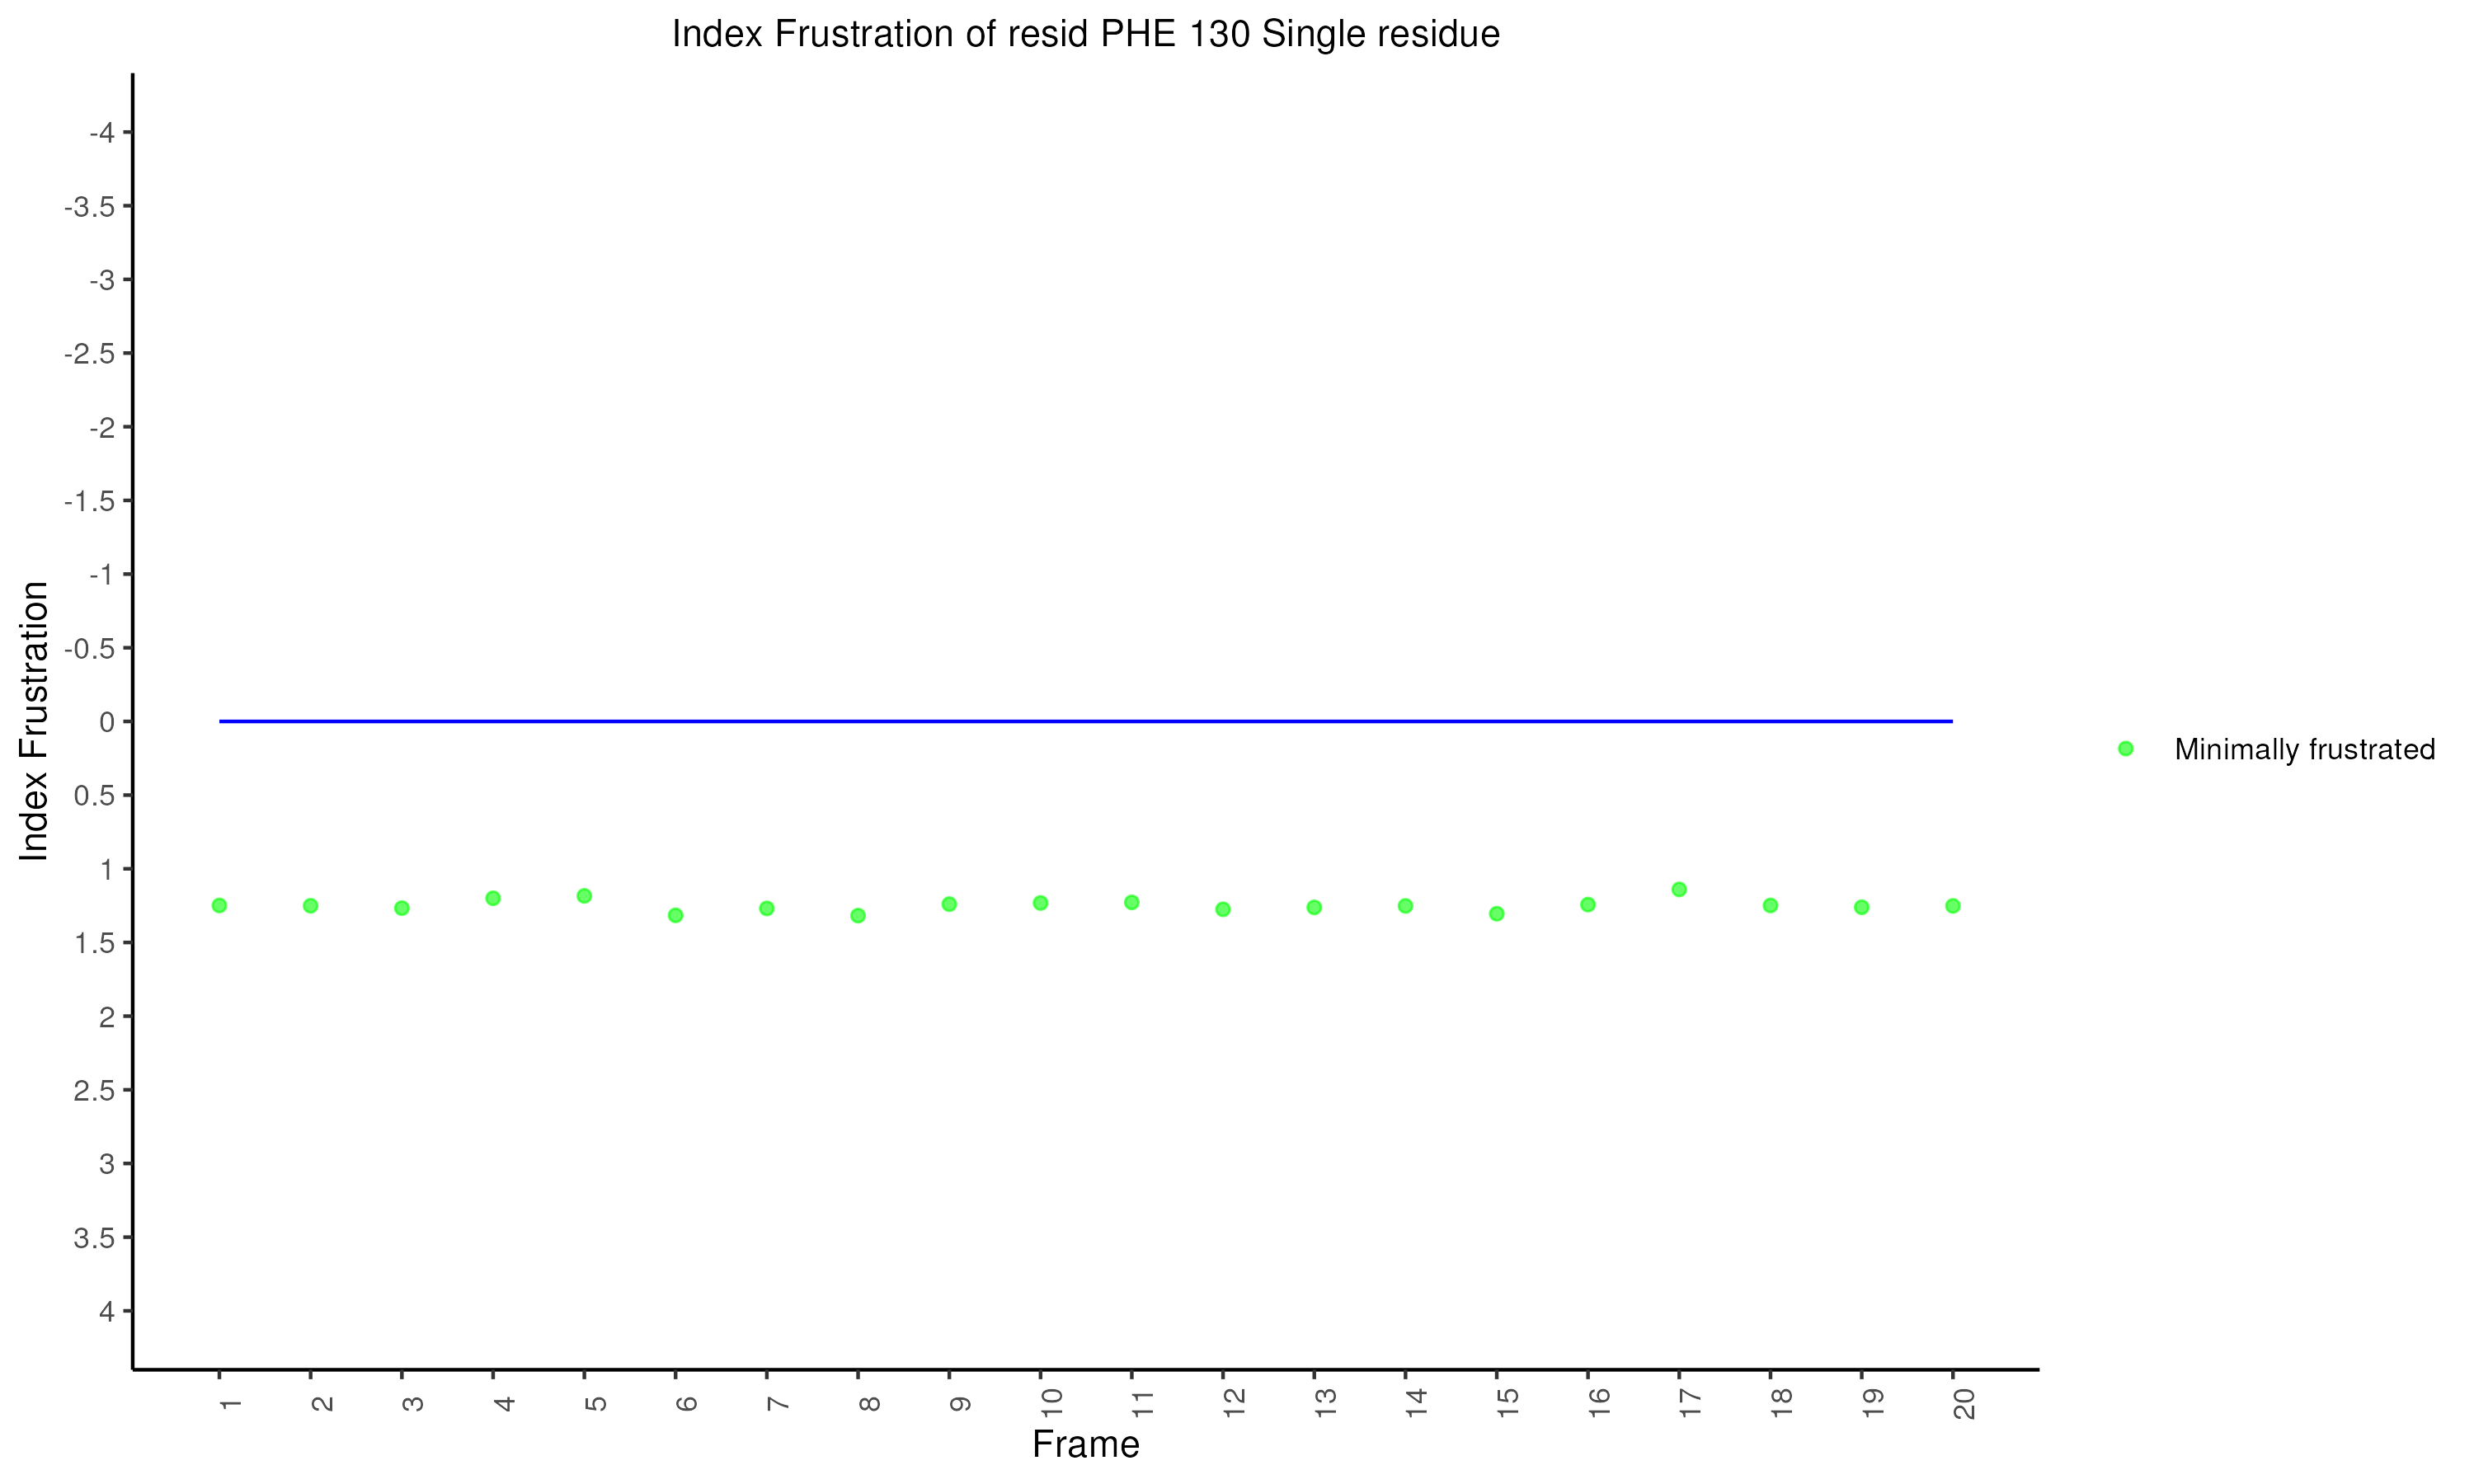

In [ ]:
from IPython.display import Image
Image('/content/Results/Dynamic_plots_res_130_A/dynamic_IndexFrustration_singleresidue_Res130.png')


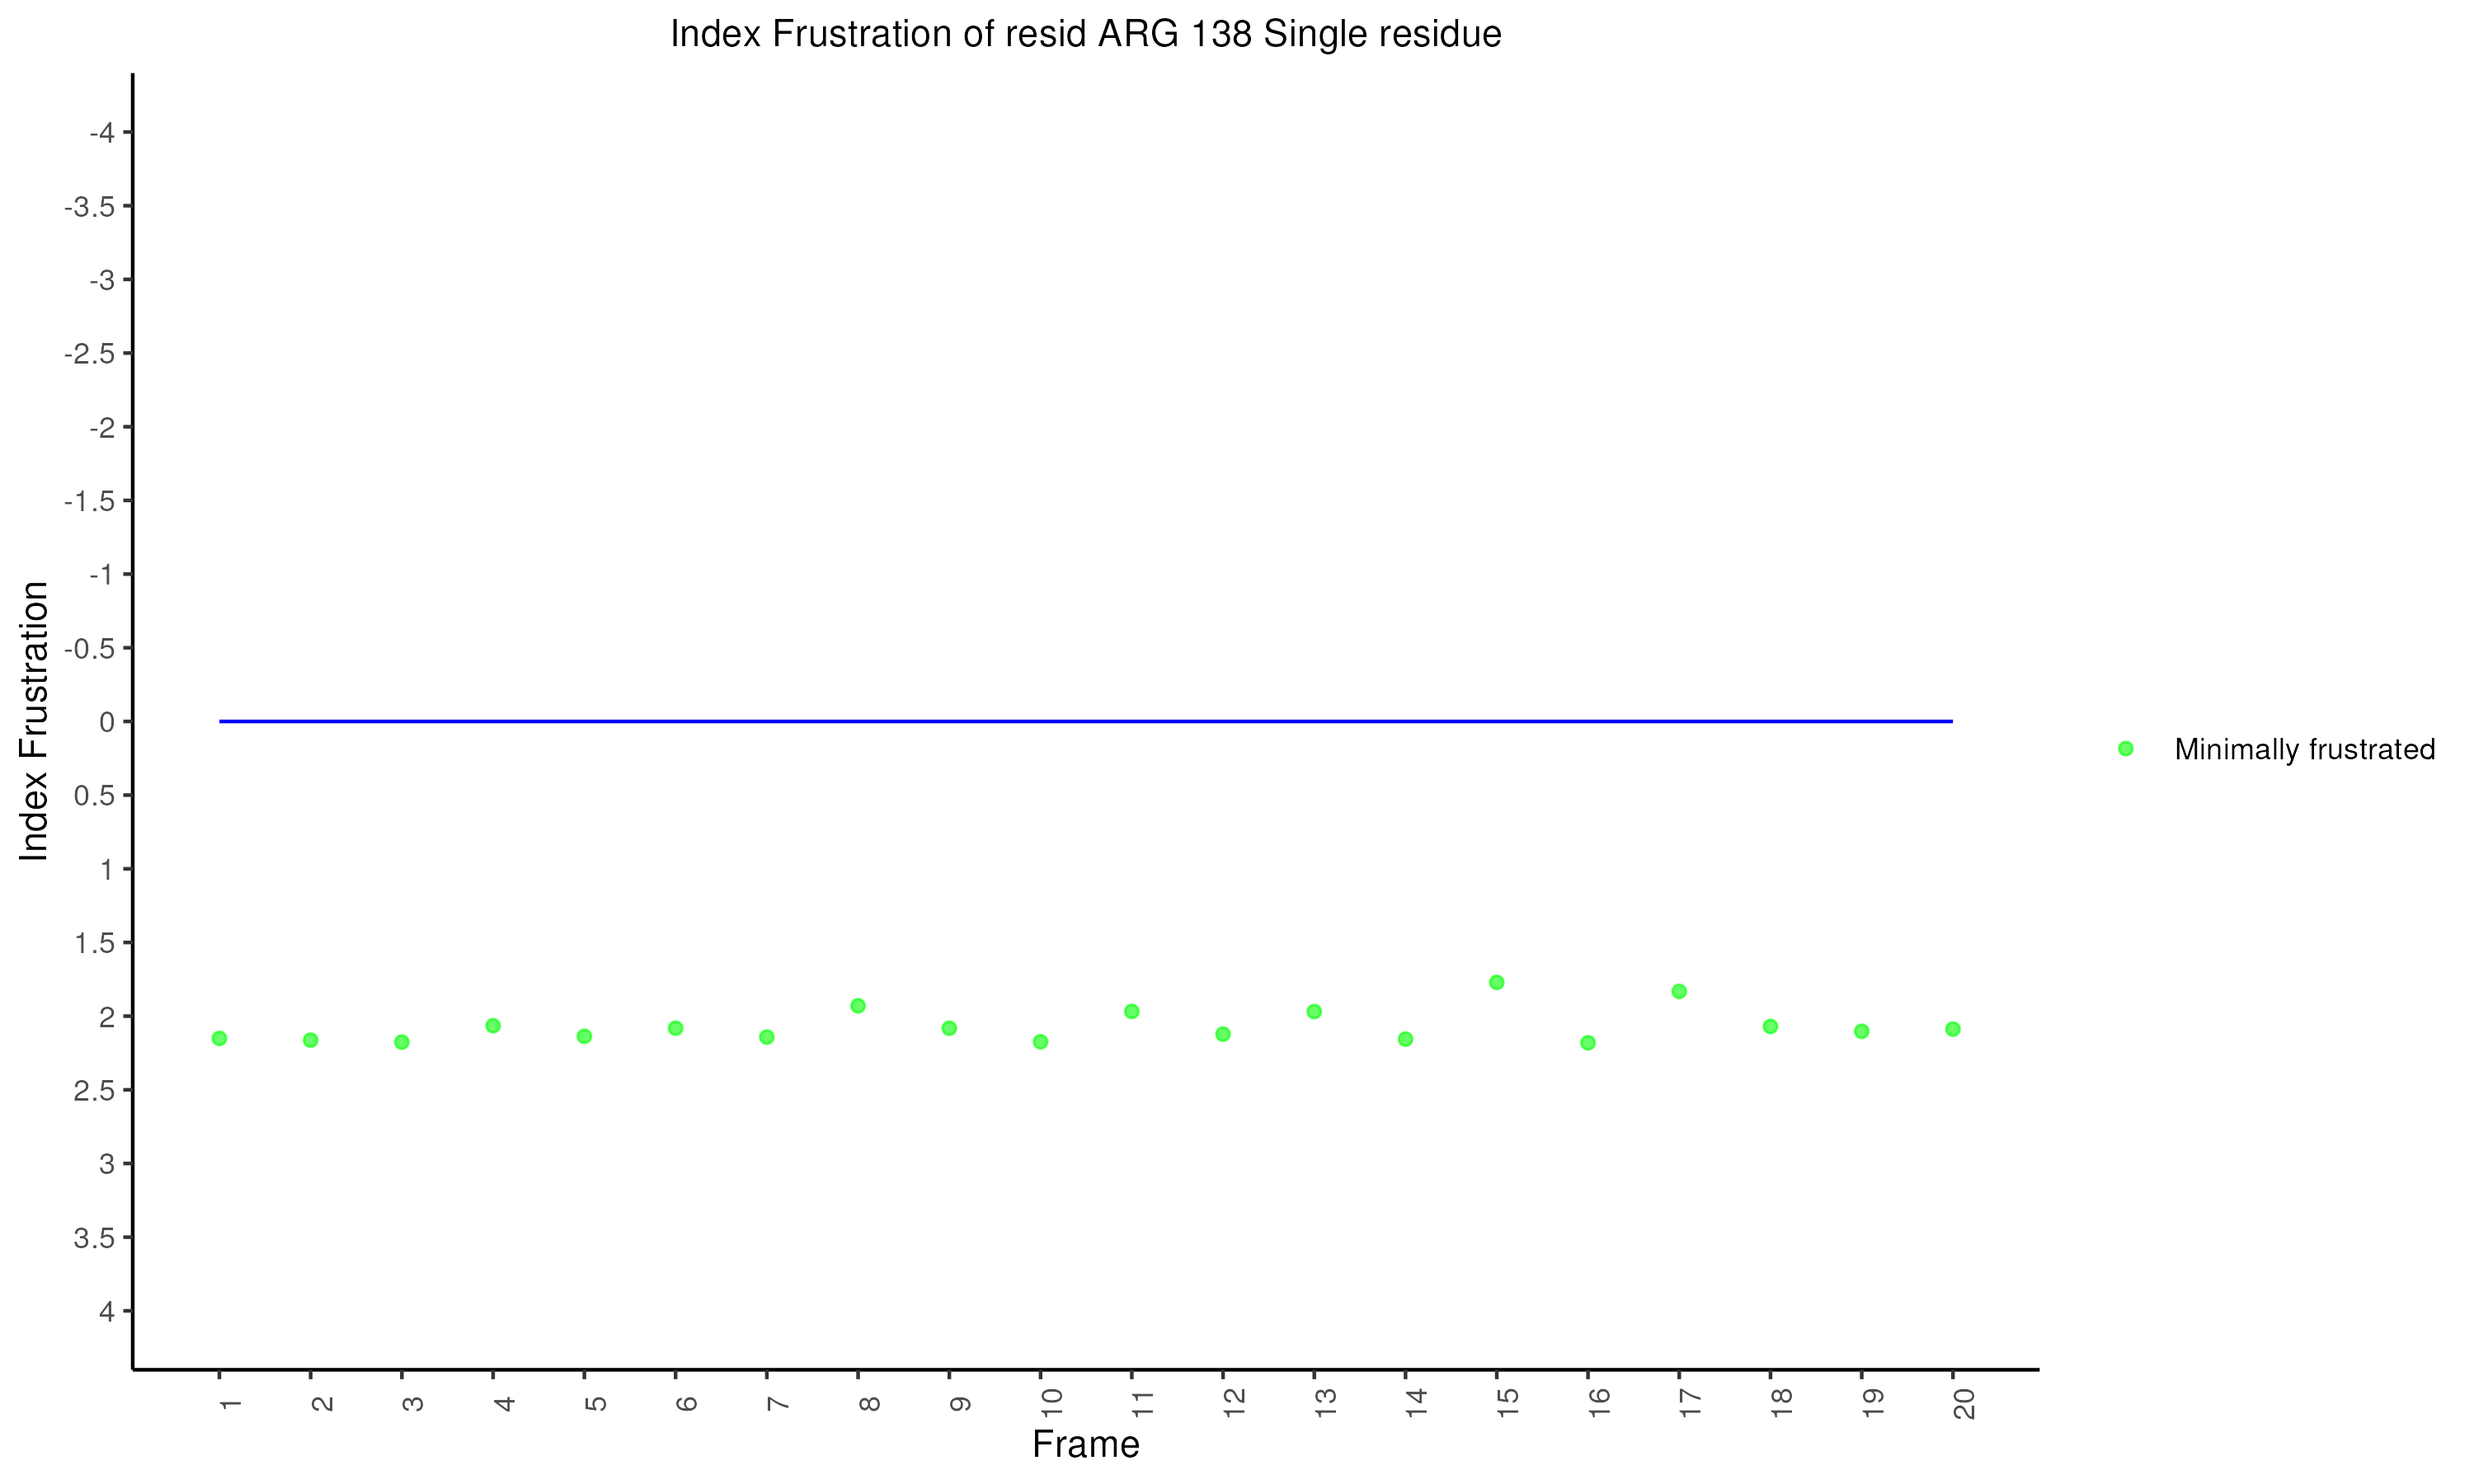

In [ ]:
Image('/content/Results/Dynamic_plots_res_138_A/dynamic_IndexFrustration_singleresidue_Res138.png')

## Ojo con el models.log a veces hay que borrar algunas lineaso agregar otras para que ocurran cosas.

In [ ]:
!tar -cvf /content/Results.tar.gz /content/Results/

tar: Removing leading `/' from member names
/content/Results/
/content/Results/2lcl12.done/
/content/Results/2lcl12.done/FrustrationData/
/content/Results/2lcl12.done/FrustrationData/2lcl12.pdb
/content/Results/2lcl12.done/FrustrationData/2lcl12.pdb_singleresidue
/content/Results/2lcl16.done/
/content/Results/2lcl16.done/FrustrationData/
/content/Results/2lcl16.done/FrustrationData/2lcl16.pdb_singleresidue
/content/Results/2lcl16.done/FrustrationData/2lcl16.pdb
/content/Results/2lcl19.done/
/content/Results/2lcl19.done/FrustrationData/
/content/Results/2lcl19.done/FrustrationData/2lcl19.pdb
/content/Results/2lcl19.done/FrustrationData/2lcl19.pdb_singleresidue
/content/Results/2lcl10.done/
/content/Results/2lcl10.done/FrustrationData/
/content/Results/2lcl10.done/FrustrationData/2lcl10.pdb_singleresidue
/content/Results/2lcl10.done/FrustrationData/2lcl10.pdb
/content/Results/2lcl.done/
/content/Results/2lcl.done/VisualizationScrips/
/content/Results/2lcl.done/VisualizationScrips/2lcl_co

In [ ]:
!tar -cvf /content/FoxP_NMR/Results.tar.gz /content/FoxP_NMR/Results/

tar: /content/FoxP_NMR/Results.tar.gz: Cannot open: No such file or directory
tar: Error is not recoverable: exiting now



# This is the final of this test colab !

























.


























## The next will be understand more about how does the frustration of a residue change during the folding and refolding process, and explore the more in deep de MD new facilities for de R-package of frustratometeR.